Loading data...
Balancing dataset...
Total features: 156 (Same as SR version)
Training LightGBM...
[LightGBM] [Info] Number of positive: 16514, number of negative: 99086
[LightGBM] [Info] Total Bins 35828
[LightGBM] [Info] Number of data points in the train set: 115600, number of used features: 153
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166664 -> initscore=-1.609458
[LightGBM] [Info] Start training from score -1.609458
[LightGBM] [Info] Number of positive: 16514, number of negative: 99086
[LightGBM] [Info] Total Bins 12462
[LightGBM] [Info] Number of data points in the train set: 115600, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166664 -> initscore=-1.609458
[LightGBM] [Info] Start training from score -1.609458
Best threshold: 0.2631
Generating full map...

NON-SR CHANGE DETECTION - COMPREHENSIVE RESULTS

--- Confusion Matrix ---
True Negatives (TN):  600,067
False Positives (FP): 3,556
False Negatives (FN): 3,699
True Positives (TP):  19,

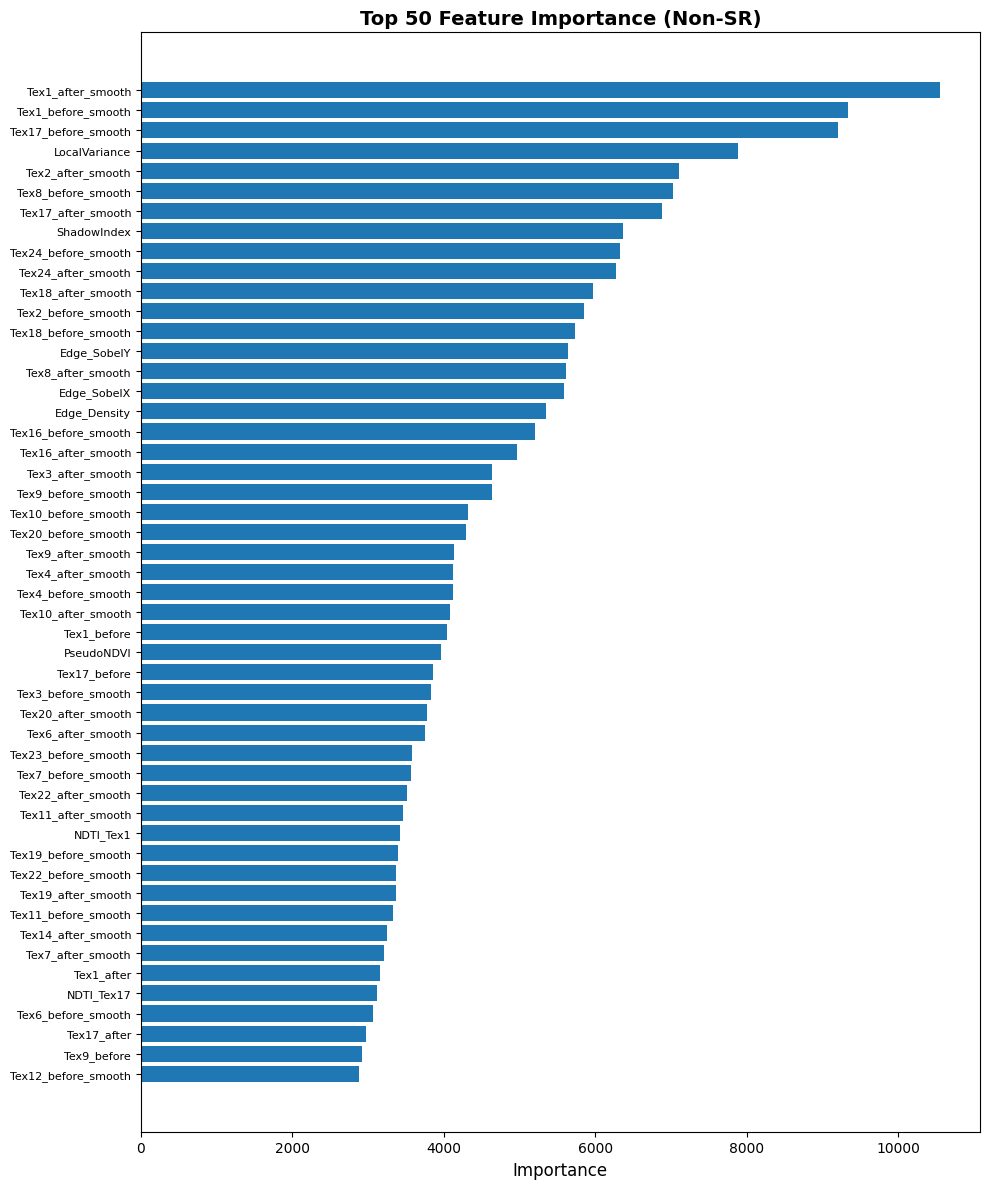

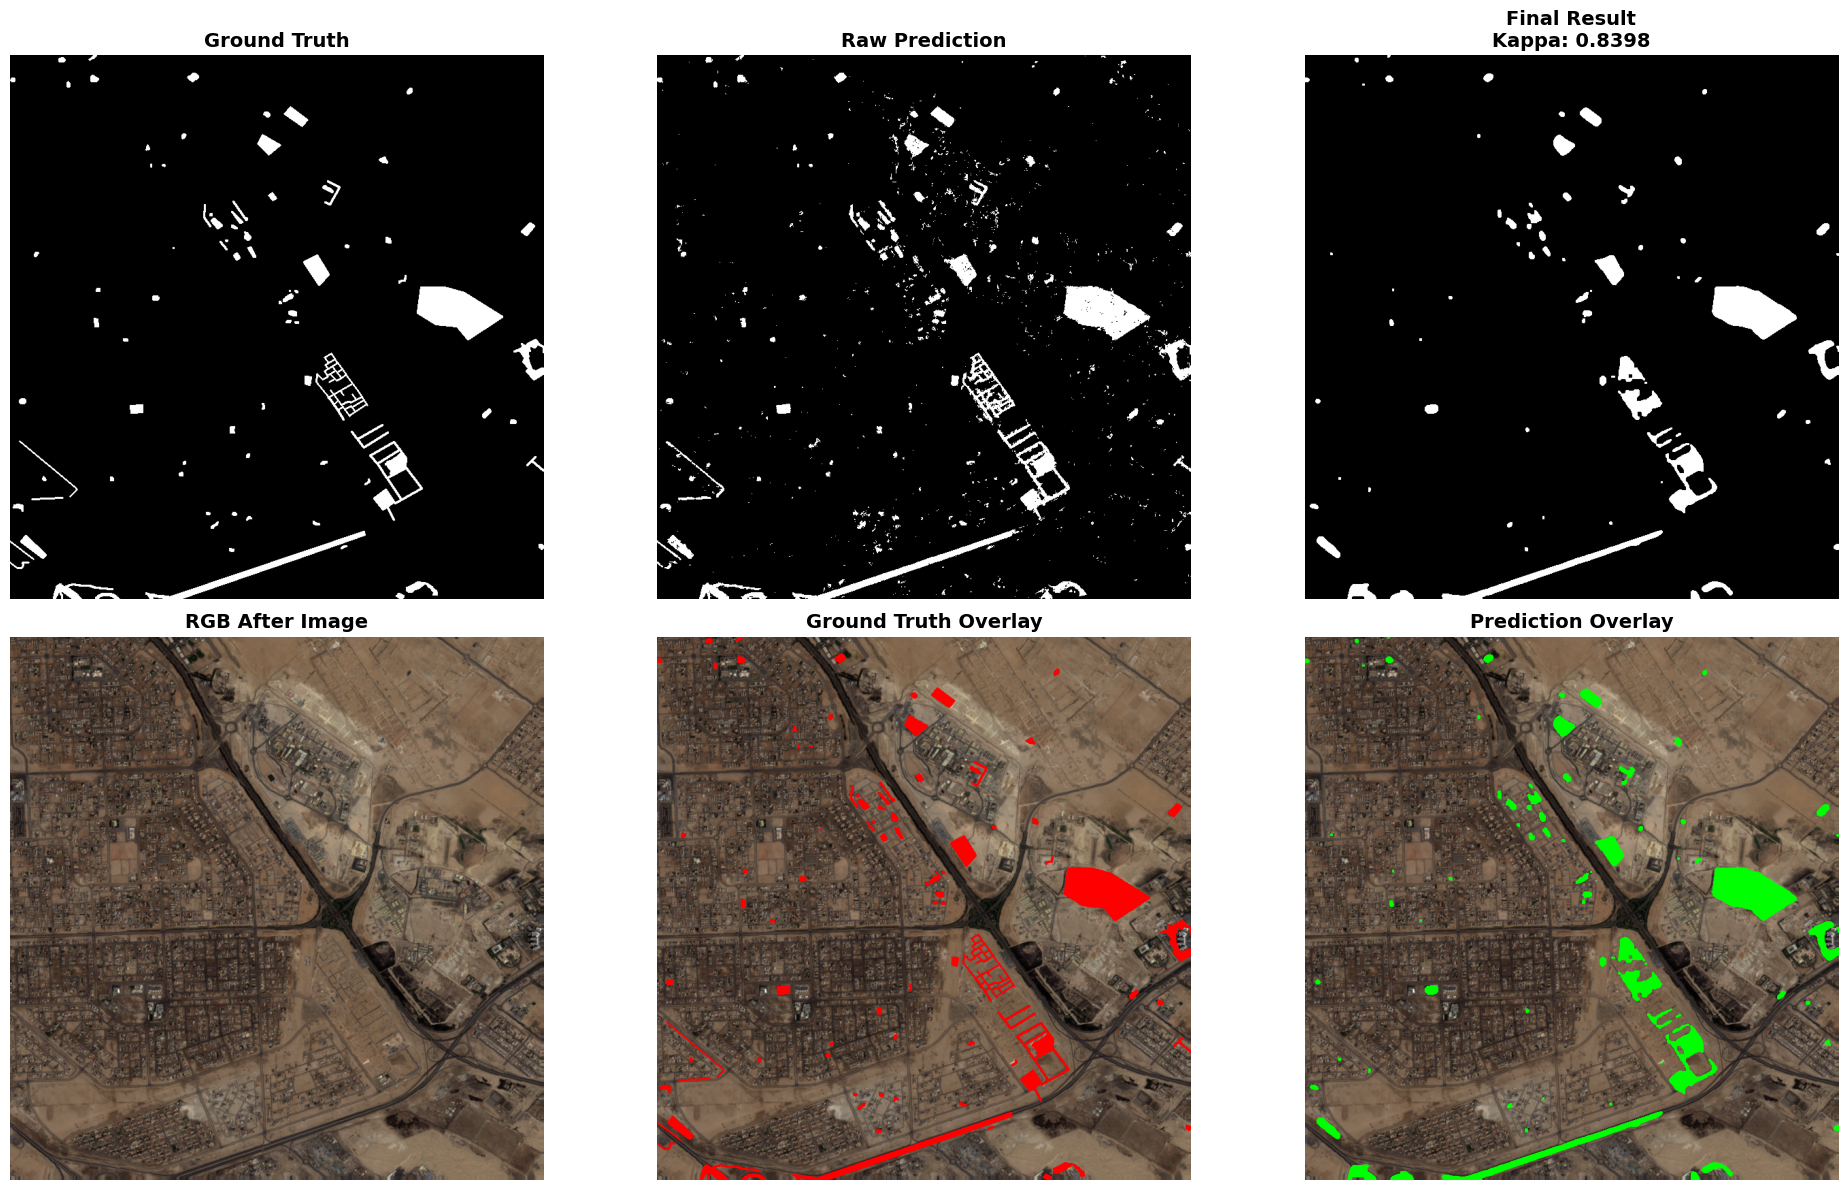

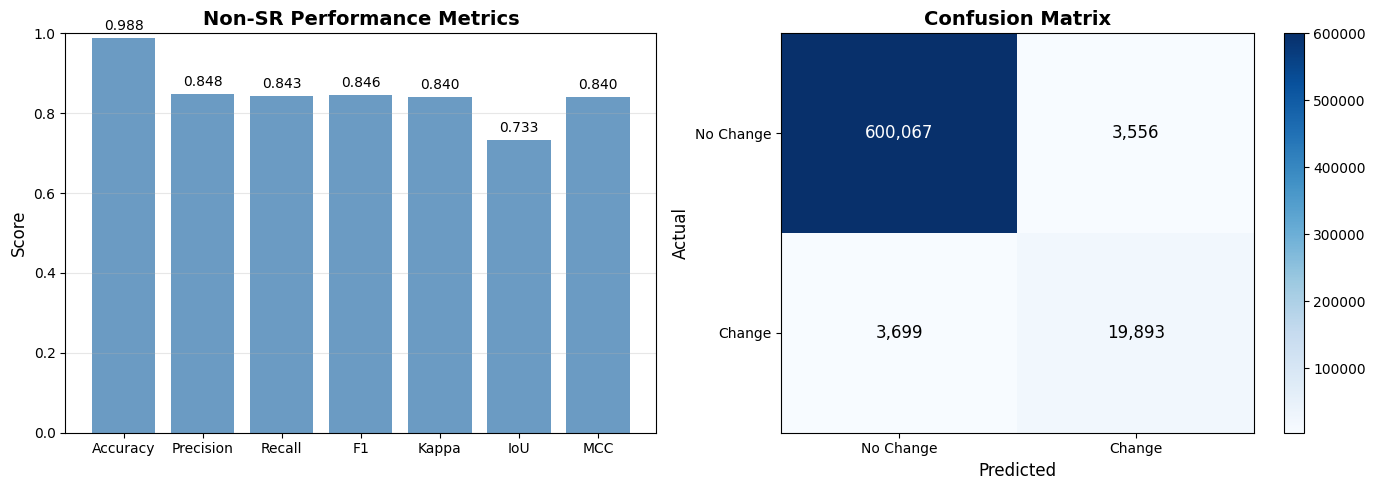


All results saved successfully!
Pipeline finished.


In [ ]:
# NON-SR CHANGE DETECTION PIPELINE V4 (Comparable with SR)

import numpy as np
import cv2
import os
import gc
import joblib
import matplotlib.pyplot as plt
import lightgbm as lgb
import warnings
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report,
    cohen_kappa_score,
    precision_recall_curve,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score
)

warnings.filterwarnings('ignore')

# ============================================================
# PATHS
# ============================================================

rows_train, cols_train, bands = 799, 785, 24

base_dir = r"F:\SR_CHANGE_DET"

path_envi_before = os.path.join(base_dir, "Non-sr", "non-sr-B-Envi-fea", "Non-sr-before")
path_envi_after  = os.path.join(base_dir, "Non-sr", "Non-sr-A-Envi-fea", "non-sr-A")
path_raw_after   = os.path.join(base_dir, "Non-sr", "non_sr_rgb_after(1).png")
mask_path        = os.path.join(base_dir, "abudhabi", "cm", "abudhabi-cm.tif")

# ============================================================
# FEATURE NAMES (SAME AS SR VERSION)
# ============================================================

texture_names = [f"Tex{i+1}" for i in range(bands)]

feature_names = []

for n in texture_names:
    feature_names.append(f"{n}_after")

for n in texture_names:
    feature_names.append(f"{n}_before")

for n in texture_names:
    feature_names.append(f"NDTI_{n}")

for n in texture_names:
    feature_names.append(f"LogRatio_{n}")

for n in texture_names:
    feature_names.append(f"{n}_after_smooth")

for n in texture_names:
    feature_names.append(f"{n}_before_smooth")

feature_names += [
    "LocalVariance",
    "PseudoNDVI",
    "Brightness",
    "ShadowIndex",
    "Edge_SobelX",
    "Edge_SobelY",
    "Edge_Gradient",
    "Edge_Laplacian",
    "Edge_Density",
    "Residual_R",
    "Residual_G",
    "Residual_B"
]

# LOAD ENVI

def load_envi_fast(path, r, c, b):
    data = np.fromfile(path, dtype=np.float32)
    data = data.reshape(b, r, c).transpose(1, 2, 0)
    return data

# EDGE FEATURES

def compute_edge_features(gray):
    sobelx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx**2 + sobely**2)
    lap = cv2.Laplacian(gray, cv2.CV_32F)
    edges = cv2.Canny(gray.astype(np.uint8), 50, 150)
    edge_density = cv2.blur(edges.astype(np.float32), (7, 7))
    return sobelx, sobely, grad_mag, lap, edge_density

# FEATURE EXTRACTION (WITH DUMMY RESIDUAL FOR COMPARISON)

def get_features_v4(envi_b, envi_a, img_var, indices, rgb_after,
                    sobelx, sobely, grad, lap, edge_den, dummy_residual):
    
    eb = envi_b.reshape(-1, bands)[indices]
    ea = envi_a.reshape(-1, bands)[indices]
    iv = img_var.flatten()[indices][:, None]
    
    rgb = rgb_after.reshape(-1, 3)[indices]
    R, G, B = rgb[:, 0], rgb[:, 1], rgb[:, 2]
    brightness = np.mean(rgb, axis=1)[:, None]
    p_ndvi = (G - R) / (G + R + 1e-6)
    p_ndvi = p_ndvi[:, None]
    shadow = (B - R) / (B + R + 1e-6)
    shadow = shadow[:, None]
    
    eps = 1e-6
    ndti = np.abs(ea - eb) / (ea + eb + eps)
    log_ratio = np.log((ea + eps) / (eb + eps))
    log_ratio = np.nan_to_num(log_ratio)
    
    ea_s = cv2.blur(envi_a, (5, 5)).reshape(-1, bands)[indices]
    eb_s = cv2.blur(envi_b, (5, 5)).reshape(-1, bands)[indices]
    
    edge_feats = np.stack([
        sobelx.flatten()[indices],
        sobely.flatten()[indices],
        grad.flatten()[indices],
        lap.flatten()[indices],
        edge_den.flatten()[indices]
    ], axis=1)
    
    residual = dummy_residual.reshape(-1, 3)[indices]
    
    return np.concatenate([
        ea, eb,
        ndti,
        log_ratio,
        ea_s, eb_s,
        iv,
        p_ndvi,
        brightness,
        shadow,
        edge_feats,
        residual
    ], axis=-1)

# LOAD DATA

print("Loading data...")

envi_b = load_envi_fast(path_envi_before, rows_train, cols_train, bands)
envi_a = load_envi_fast(path_envi_after, rows_train, cols_train, bands)

raw_rgb = cv2.imread(path_raw_after)
raw_rgb = cv2.cvtColor(raw_rgb, cv2.COLOR_BGR2RGB)
raw_rgb = cv2.resize(raw_rgb, (cols_train, rows_train))
raw_rgb = raw_rgb.astype(np.float32) / 255

# LOCAL VARIANCE

gray = cv2.cvtColor((raw_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32)
mean = cv2.blur(gray, (7, 7))
img_var = np.sqrt(np.maximum(cv2.blur(gray**2, (7, 7)) - mean**2, 0))

# EDGE FEATURES

sobelx, sobely, grad, lap, edge_den = compute_edge_features(gray)

# DUMMY RESIDUAL (FOR FAIR COMPARISON)

dummy_residual = np.zeros((rows_train, cols_train, 3), dtype=np.float32)

# LOAD MASK

mask = cv2.imread(mask_path, 0)
mask = cv2.resize(mask, (cols_train, rows_train), interpolation=cv2.INTER_NEAREST)
y_all = (mask.flatten() == 2).astype(np.uint8)


# BALANCE DATA
print("Balancing dataset...")

idx_change = np.where(y_all == 1)[0]
idx_no_change = np.random.choice(
    np.where(y_all == 0)[0],
    size=len(idx_change) * 6,
    replace=False
)

all_idx = np.concatenate([idx_change, idx_no_change])

X = get_features_v4(
    envi_b, envi_a, img_var,
    all_idx,
    raw_rgb,
    sobelx, sobely, grad, lap, edge_den,
    dummy_residual
)

y = y_all[all_idx]

print(f"Total features: {X.shape[1]} (Same as SR version)")

# TRAIN TEST

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# TRAIN MODEL

print("Training LightGBM...")

model = lgb.LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    num_leaves=255,
    class_weight={0: 1, 1: 1.2},
    force_col_wise=True
)

model.fit(X_train, y_train)

# FEATURE SELECTION


importances = model.feature_importances_
top50 = np.argsort(importances)[-50:]
top50_names = [feature_names[i] for i in top50]

X_train = X_train[:, top50]
X_test = X_test[:, top50]

model.fit(X_train, y_train)

# THRESHOLD OPTIMIZATION

probs = model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_th = thresholds[np.argmax(f1_scores)]

print(f"Best threshold: {best_th:.4f}")

# FULL MAP PREDICTION

print("Generating full map...")

full_pred = np.zeros(rows_train * cols_train, dtype=np.uint8)
step = 400

for r in range(0, rows_train, step):
    r_end = min(r + step, rows_train)
    indices = np.arange(r * cols_train, r_end * cols_train)
    
    X_block = get_features_v4(
        envi_b, envi_a, img_var,
        indices,
        raw_rgb,
        sobelx, sobely, grad, lap, edge_den,
        dummy_residual
    )
    
    X_block = scaler.transform(X_block)
    X_block = X_block[:, top50]
    
    probs = model.predict_proba(X_block)[:, 1]
    full_pred[indices] = (probs >= best_th).astype(np.uint8)
    
    del X_block
    gc.collect()

final_map = full_pred.reshape(rows_train, cols_train)

# POST PROCESSING

final_clean = cv2.medianBlur(final_map.astype(np.uint8), 9)

kernel = np.ones((5, 5), np.uint8)
final_clean = cv2.morphologyEx(final_clean, cv2.MORPH_CLOSE, kernel)

kernel = np.ones((3, 3), np.uint8)
final_clean = cv2.morphologyEx(final_clean, cv2.MORPH_OPEN, kernel)

# COMPREHENSIVE METRICS

y_true = y_all
y_pred = final_clean.flatten()

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

# All Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
iou = jaccard_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)

# Specificity
specificity = tn / (tn + fp)

# False Positive Rate
fpr = fp / (fp + tn)

# False Negative Rate
fnr = fn / (fn + tp)

print("\n" + "="*60)
print("NON-SR CHANGE DETECTION - COMPREHENSIVE RESULTS")
print("="*60)

print("\n--- Confusion Matrix ---")
print(f"True Negatives (TN):  {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives (TP):  {tp:,}")

print("\n--- Primary Metrics ---")
print(f"Overall Accuracy:     {accuracy:.4f}")
print(f"Balanced Accuracy:    {bal_acc:.4f}")
print(f"Precision:            {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity:          {specificity:.4f}")
print(f"F1-Score:             {f1:.4f}")

print("\n--- Advanced Metrics ---")
print(f"Cohen's Kappa:        {kappa:.4f}")
print(f"IoU (Jaccard):        {iou:.4f}")
print(f"Matthews Corr Coef:   {mcc:.4f}")

print("\n--- Error Rates ---")
print(f"False Positive Rate:  {fpr:.4f}")
print(f"False Negative Rate:  {fnr:.4f}")

print("\n" + classification_report(y_true, y_pred, target_names=['No Change', 'Change']))

print("="*60)


# SAVE METRICS TO FILE

metrics_dict = {
    'Method': 'Non-SR',
    'Total_Features': X.shape[1],
    'Selected_Features': 50,
    'Accuracy': accuracy,
    'Balanced_Accuracy': bal_acc,
    'Precision': precision,
    'Recall': recall,
    'Specificity': specificity,
    'F1_Score': f1,
    'Kappa': kappa,
    'IoU': iou,
    'MCC': mcc,
    'FPR': fpr,
    'FNR': fnr,
    'TP': tp,
    'TN': tn,
    'FP': fp,
    'FN': fn,
    'Best_Threshold': best_th
}

df_metrics = pd.DataFrame([metrics_dict])
df_metrics.to_csv(os.path.join(base_dir, "NonSR_V4_Metrics.csv"), index=False)

# FEATURE IMPORTANCE PLOT

plt.figure(figsize=(10, 12))
plt.barh(range(50), importances[top50])
plt.yticks(range(50), top50_names, fontsize=8)
plt.xlabel('Importance', fontsize=12)
plt.title("Top 50 Feature Importance (Non-SR)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "NonSR_V4_FeatureImportance.png"), dpi=300)

# COMPREHENSIVE VISUALIZATION

fig = plt.figure(figsize=(20, 12))

# Ground Truth
plt.subplot(2, 3, 1)
plt.imshow(mask == 2, cmap='gray')
plt.title("Ground Truth", fontsize=14, fontweight='bold')
plt.axis('off')

# Raw Prediction
plt.subplot(2, 3, 2)
plt.imshow(final_map, cmap='gray')
plt.title("Raw Prediction", fontsize=14, fontweight='bold')
plt.axis('off')

# Final Cleaned
plt.subplot(2, 3, 3)
plt.imshow(final_clean, cmap='gray')
plt.title(f"Final Result\nKappa: {kappa:.4f}", fontsize=14, fontweight='bold')
plt.axis('off')

# RGB Image
plt.subplot(2, 3, 4)
plt.imshow(raw_rgb)
plt.title("RGB After Image", fontsize=14, fontweight='bold')
plt.axis('off')

# Overlay: Ground Truth on RGB
plt.subplot(2, 3, 5)
overlay_gt = raw_rgb.copy()
overlay_gt[mask == 2] = [1, 0, 0]
plt.imshow(overlay_gt)
plt.title("Ground Truth Overlay", fontsize=14, fontweight='bold')
plt.axis('off')

# Overlay: Prediction on RGB
plt.subplot(2, 3, 6)
overlay_pred = raw_rgb.copy()
overlay_pred[final_clean == 1] = [0, 1, 0]
plt.imshow(overlay_pred)
plt.title("Prediction Overlay", fontsize=14, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(base_dir, "NonSR_V4_Comprehensive_Result.png"), dpi=300)
plt.show()

# METRICS COMPARISON PLOT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of main metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'Kappa', 'IoU', 'MCC']
metrics_values = [accuracy, precision, recall, f1, kappa, iou, mcc]

axes[0].bar(metrics_names, metrics_values, color='steelblue', alpha=0.8)
axes[0].set_ylim([0, 1])
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Non-SR Performance Metrics', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(metrics_values):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
im = axes[1].imshow(cm, cmap='Blues', aspect='auto')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['No Change', 'Change'])
axes[1].set_yticklabels(['No Change', 'Change'])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{cm[i, j]:,}', ha='center', va='center', 
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=12)

plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "NonSR_V4_Metrics_Plot.png"), dpi=300)
plt.show()

# SAVE

joblib.dump(model, os.path.join(base_dir, "NonSR_LGBM_V4_model.pkl"))
joblib.dump(scaler, os.path.join(base_dir, "NonSR_LGBM_V4_scaler.pkl"))
joblib.dump(top50, os.path.join(base_dir, "NonSR_LGBM_V4_top50_indices.pkl"))
joblib.dump(top50_names, os.path.join(base_dir, "NonSR_LGBM_V4_top50_names.pkl"))

cv2.imwrite(os.path.join(base_dir, "NonSR_Final_Map_V4.png"), final_clean * 255)

print("\nAll results saved successfully!")
print("Pipeline finished.")


In [ ]:
# ADDITIONAL METRICS: BOUNDARY IoU & HAUSDORFF DISTANCE

from scipy.spatial.distance import directed_hausdorff

def compute_boundary_iou(y_true, y_pred, rows, cols):
    """Compute IoU on boundary pixels only"""
    gt_map = y_true.reshape(rows, cols).astype(np.uint8)
    pred_map = y_pred.reshape(rows, cols).astype(np.uint8)
    
    # Extract boundaries using morphological operations
    kernel = np.ones((3, 3), np.uint8)
    gt_boundary = cv2.morphologyEx(gt_map, cv2.MORPH_GRADIENT, kernel)
    pred_boundary = cv2.morphologyEx(pred_map, cv2.MORPH_GRADIENT, kernel)
    
    # Compute IoU on boundaries
    intersection = np.logical_and(gt_boundary, pred_boundary).sum()
    union = np.logical_or(gt_boundary, pred_boundary).sum()
    
    return intersection / (union + 1e-9)

def compute_hausdorff_distance(y_true, y_pred, rows, cols):
    """Compute Hausdorff distance between change regions"""
    gt_map = y_true.reshape(rows, cols).astype(np.uint8)
    pred_map = y_pred.reshape(rows, cols).astype(np.uint8)
    
    # Get coordinates of change pixels
    gt_coords = np.argwhere(gt_map == 1)
    pred_coords = np.argwhere(pred_map == 1)
    
    if len(gt_coords) == 0 or len(pred_coords) == 0:
        return np.inf
    
    # Compute Hausdorff distance
    hd1 = directed_hausdorff(gt_coords, pred_coords)[0]
    hd2 = directed_hausdorff(pred_coords, gt_coords)[0]
    
    return max(hd1, hd2)

# Compute additional metrics
boundary_iou = compute_boundary_iou(y_true, y_pred, rows_train, cols_train)
hausdorff_dist = compute_hausdorff_distance(y_true, y_pred, rows_train, cols_train)

print("\n--- Boundary & Distance Metrics ---")
print(f"Boundary IoU:         {boundary_iou:.4f}")
print(f"Hausdorff Distance:   {hausdorff_dist:.2f}")

# Update metrics dictionary
metrics_dict['Boundary_IoU'] = boundary_iou
metrics_dict['Hausdorff_Distance'] = hausdorff_dist

# Re-save updated metrics
df_metrics = pd.DataFrame([metrics_dict])
df_metrics.to_csv(os.path.join(base_dir, "NonSR_V4_Metrics.csv"), index=False)



--- Boundary & Distance Metrics ---
Boundary IoU:         0.4068
Hausdorff Distance:   89.31


Loading ENVI images...
Before shape: (799, 785, 24)
After shape : (799, 785, 24)
Computing edge features...
Feature stack shape: (799, 785, 168)
Dataset size: (627215, 168)
Training LightGBM...
[LightGBM] [Info] Number of positive: 7078, number of negative: 181086
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.172500 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 39974
[LightGBM] [Info] Number of data points in the train set: 188164, number of used features: 168
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.037616 -> initscore=-3.241981
[LightGBM] [Info] Start training from score -3.241981


f:\anaconda\envs\remote_sensing\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Results NON-SR
Accuracy : 0.9709965357099745
F1 Score : 0.9851098809866253
Kappa    : 0.4321087326775328

Confusion Matrix
[[421232   1305]
 [ 11429   5085]]


f:\anaconda\envs\remote_sensing\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Outputs saved in: F:\SR_CHANGE_DET\Results_nonSR_V4


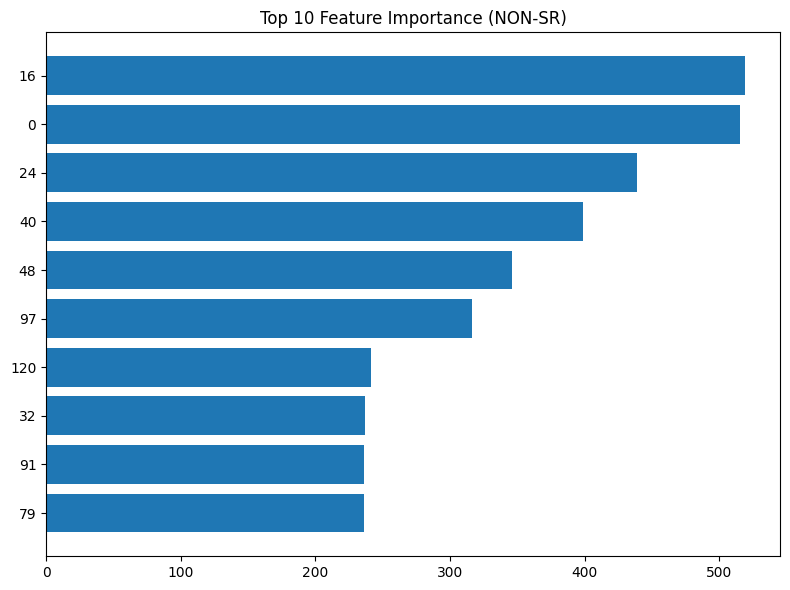

In [ ]:
import os
import numpy as np
import cv2
import spectral
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix



rows_train, cols_train, bands = 799, 785, 24

base_dir = r"F:\SR_CHANGE_DET"

path_envi_before = os.path.join(base_dir, "Non-sr", "non-sr-B-Envi-fea", "Non-sr-before")
path_envi_after  = os.path.join(base_dir, "Non-sr", "Non-sr-A-Envi-fea", "non-sr-A")

path_raw_after   = os.path.join(base_dir, "Non-sr", "non_sr_rgb_after(1).png")

mask_path        = os.path.join(base_dir, "abudhabi", "cm", "abudhabi-cm.tif")

output_dir = os.path.join(base_dir, "Results_nonSR_V4")
os.makedirs(output_dir, exist_ok=True)

# reading ENVI 

print("Loading ENVI images...")

before = spectral.open_image(path_envi_before + ".hdr").load()
after  = spectral.open_image(path_envi_after + ".hdr").load()

before = np.asarray(before).astype(np.float32)
after  = np.asarray(after).astype(np.float32)

print("Before shape:", before.shape)
print("After shape :", after.shape)

# 3. Residual


residual = after - before

# 4. Edge Features (Sobel)

def sobel_features(img):

    feats = []

    for b in range(img.shape[2]):

        band = img[:,:,b]

        sx = cv2.Sobel(band, cv2.CV_32F,1,0,ksize=3)
        sy = cv2.Sobel(band, cv2.CV_32F,0,1,ksize=3)

        mag = np.sqrt(sx**2 + sy**2)

        feats.append(mag)

    return np.stack(feats,axis=2)

print("Computing edge features...")

edge_before = sobel_features(before)
edge_after  = sobel_features(after)

# -------------------------------------------------
# 5. Log Ratio
# -------------------------------------------------

eps = 1e-6

before_safe = np.maximum(before, eps)
after_safe  = np.maximum(after, eps)

log_ratio = np.log(after_safe / before_safe)

# -------------------------------------------------
# 6. NDTI
# -------------------------------------------------

ndti = (after-before)/(after+before+eps)

# -------------------------------------------------
# 7. Feature Stack
# -------------------------------------------------

features = np.concatenate([
    before,
    after,
    residual,
    edge_before,
    edge_after,
    log_ratio,
    ndti
],axis=2)

print("Feature stack shape:",features.shape)

# -------------------------------------------------
# 8. reshape
# -------------------------------------------------

X = features.reshape(-1,features.shape[2])

# -------------------------------------------------
# 9. Load Change Mask
# -------------------------------------------------

mask = cv2.imread(mask_path,0)

if mask is None:
    raise ValueError(f"Mask not found: {mask_path}")

mask = cv2.resize(mask,(cols_train,rows_train),interpolation=cv2.INTER_NEAREST)

y = mask.flatten()

print("Dataset size:",X.shape)

# -------------------------------------------------
# 10. Train/Test split
# -------------------------------------------------

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.7,
    random_state=42,
    stratify=y
)

# -------------------------------------------------
# 11. LightGBM
# -------------------------------------------------

print("Training LightGBM...")

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=64,
    n_jobs=-1
)

model.fit(X_train,y_train)

# -------------------------------------------------
# 12. Evaluation
# -------------------------------------------------

pred = model.predict(X_test)

acc = accuracy_score(y_test,pred)
f1 = f1_score(y_test,pred)
kappa = cohen_kappa_score(y_test,pred)

cm = confusion_matrix(y_test,pred)

print("\nResults NON-SR")

print("Accuracy :",acc)
print("F1 Score :",f1)
print("Kappa    :",kappa)

print("\nConfusion Matrix")
print(cm)

# -------------------------------------------------
# 13. Predict full image
# -------------------------------------------------

full_pred = model.predict(X)

change_map = full_pred.reshape(rows_train,cols_train)

# -------------------------------------------------
# 14. Save change map
# -------------------------------------------------

out_map = os.path.join(output_dir,"change_map_nonSR.png")

cv2.imwrite(out_map,change_map*255)

# -------------------------------------------------
# 15. Feature Importance
# -------------------------------------------------

importances = model.feature_importances_

idx = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(8,6))

plt.barh(range(10),importances[idx][::-1])

plt.yticks(range(10),idx[::-1])

plt.title("Top 10 Feature Importance (NON-SR)")

plt.tight_layout()

plt.savefig(os.path.join(output_dir,"FeatureImportance_nonSR.png"),dpi=300)

print("\nOutputs saved in:",output_dir)


In [5]:
gt = cv2.imread(gt_path,0)

print("GT path:", gt_path)
print("GT loaded:", gt is not None)

GT path: F:\SR_CHANGE_DET\GT\gt.png
GT loaded: False


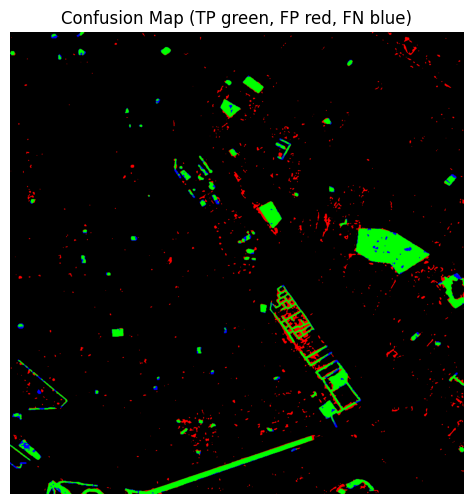

In [18]:
conf = np.zeros((rows_train,cols_train,3))

gt = gt_map
pr = pred_map

tp = (gt==1)&(pr==1)
fp = (gt==0)&(pr==1)
fn = (gt==1)&(pr==0)

conf[tp] = [0,1,0]
conf[fp] = [1,0,0]
conf[fn] = [0,0,1]

plt.figure(figsize=(6,6))
plt.title("Confusion Map (TP green, FP red, FN blue)")
plt.imshow(conf)
plt.axis("off")
plt.show()


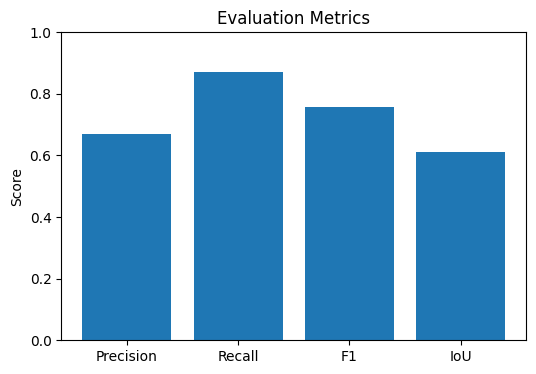

In [19]:
metrics = {
    "Precision":precision,
    "Recall":recall,
    "F1":f1,
    "IoU":iou
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(),metrics.values())
plt.ylim(0,1)
plt.title("Evaluation Metrics")
plt.ylabel("Score")
plt.show()


In [16]:
# ============================================================
# EXTRA METRICS
# ============================================================

precision = np.sum((y_pred==1) & (y_true==1)) / (np.sum(y_pred==1)+1e-9)
recall    = np.sum((y_pred==1) & (y_true==1)) / (np.sum(y_true==1)+1e-9)

f1 = 2*(precision*recall)/(precision+recall+1e-9)

print("Precision:",precision)
print("Recall:",recall)
print("F1:",f1)


# ============================================================
# CONFUSION MATRIX
# ============================================================

tp = np.sum((y_pred==1) & (y_true==1))
tn = np.sum((y_pred==0) & (y_true==0))
fp = np.sum((y_pred==1) & (y_true==0))
fn = np.sum((y_pred==0) & (y_true==1))

print("TP:",tp)
print("TN:",tn)
print("FP:",fp)
print("FN:",fn)


# ============================================================
# BOUNDARY METRICS
# ============================================================

gt_map = y_true.reshape(rows_train,cols_train)
pred_map = final_clean

gt_boundary = find_boundaries(gt_map,mode='outer')
pred_boundary = find_boundaries(pred_map,mode='outer')

gt_pts = np.column_stack(np.where(gt_boundary))
pr_pts = np.column_stack(np.where(pred_boundary))

haus1 = directed_hausdorff(gt_pts,pr_pts)[0]
haus2 = directed_hausdorff(pr_pts,gt_pts)[0]

hausdorff = max(haus1,haus2)

intersection = np.logical_and(gt_boundary,pred_boundary).sum()
union = np.logical_or(gt_boundary,pred_boundary).sum()

boundary_iou = intersection/(union+1e-9)

print("Boundary IoU:",boundary_iou)
print("Hausdorff Distance:",hausdorff)


Precision: 0.6695482981634668
Recall: 0.8724302729738872
F1: 0.7576424408106786
TP: 329318
TN: 9495435
FP: 162533
FN: 48154
Boundary IoU: 0.0405586802897678
Hausdorff Distance: 746.0


Loading data...
Balancing dataset...
Training LightGBM...
[LightGBM] [Info] Number of positive: 264230, number of negative: 1585382
[LightGBM] [Info] Total Bins 36141
[LightGBM] [Info] Number of data points in the train set: 1849612, number of used features: 156
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166666 -> initscore=-1.609439
[LightGBM] [Info] Start training from score -1.609439
[LightGBM] [Info] Number of positive: 264230, number of negative: 1585382
[LightGBM] [Info] Total Bins 12520
[LightGBM] [Info] Number of data points in the train set: 1849612, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166666 -> initscore=-1.609439
[LightGBM] [Info] Start training from score -1.609439
Best threshold: 0.3877427980581126
Generating full map...
Kappa: 0.7692
IoU: 0.6377
MCC: 0.7736
Balanced Accuracy: 0.9265
Precision: 0.7068
Recall: 0.8670
F1-score: 0.7788
Boundary IoU: 0.0553
Hausdorff Distance: 106857.00

Classification Report:
              prec

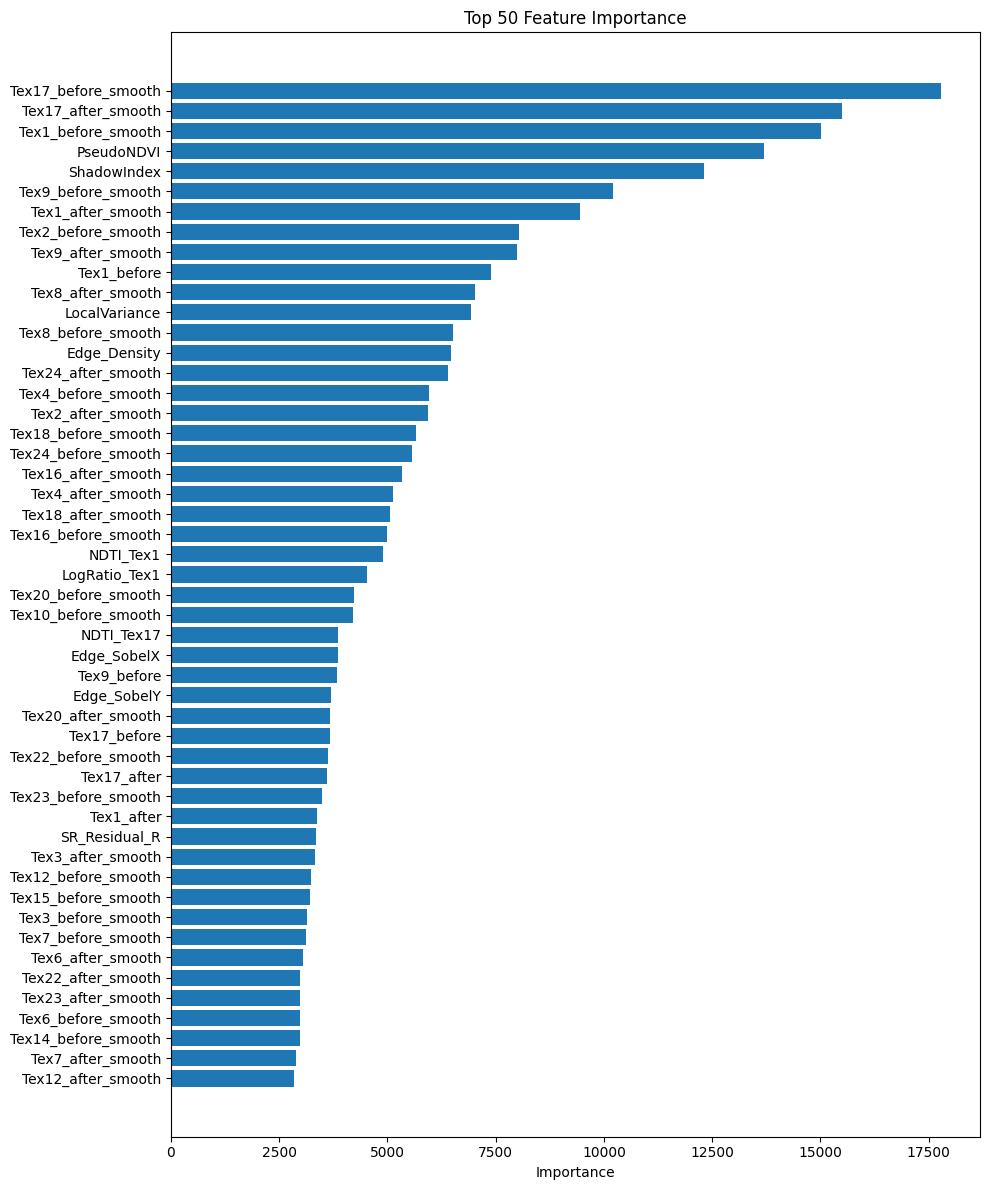

Pipeline finished.


In [ ]:
# **********************
# For choice Sr - Real Esrgan 
import numpy as np
import cv2
import os
import gc
import joblib
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report,
    cohen_kappa_score,
    precision_recall_curve,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_score,
    recall_score,
)
from skimage.segmentation import find_boundaries
from scipy.spatial.distance import directed_hausdorff


# ===========================
# PATHS AND GLOBAL PARAMETERS
# ===========================

rows_train, cols_train, bands = 3196, 3140, 24

base_dir = r"F:\SR_CHANGE_DET"

path_envi_before = os.path.join(base_dir, "Real_Gan", "before_TEX", "FILE_before")
path_envi_after = os.path.join(base_dir, "Real_Gan", "after_TEXTure", "File_after")
path_raw_after = os.path.join(base_dir, "Real_Gan", "sr_after.png")

mask_path = os.path.join(base_dir, "abudhabi", "cm", "abudhabi-cm.tif")

# ===================
# FEATURE NAMES SETUP
# ===================

texture_names = [f"Tex{i+1}" for i in range(bands)]

feature_names = []

for n in texture_names:
    feature_names.append(f"{n}_after")

for n in texture_names:
    feature_names.append(f"{n}_before")

for n in texture_names:
    feature_names.append(f"NDTI_{n}")

for n in texture_names:
    feature_names.append(f"LogRatio_{n}")

for n in texture_names:
    feature_names.append(f"{n}_after_smooth")

for n in texture_names:
    feature_names.append(f"{n}_before_smooth")

feature_names += [
    "LocalVariance",
    "PseudoNDVI",
    "Brightness",
    "ShadowIndex",
    "Edge_SobelX",
    "Edge_SobelY",
    "Edge_Gradient",
    "Edge_Laplacian",
    "Edge_Density",
    "SR_Residual_R",
    "SR_Residual_G",
    "SR_Residual_B"
]


# =============================
# LOAD ENVI DATA HELPER FUNCTION
# =============================

def load_envi_fast(path, r, c, b):
    data = np.fromfile(path, dtype=np.float32)
    data = data.reshape(b, r, c).transpose(1, 2, 0)
    return data


# ========================
# EDGE FEATURE EXTRACTION
# ========================

def compute_edge_features(gray):
    sobelx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx ** 2 + sobely ** 2)
    lap = cv2.Laplacian(gray, cv2.CV_32F)
    edges = cv2.Canny(gray.astype(np.uint8), 30, 100)  # حساس‌تر به لبه‌ها
    edge_density = cv2.blur(edges.astype(np.float32), (7, 7))
    return sobelx, sobely, grad_mag, lap, edge_density


# ==================
# FEATURE EXTRACTION
# ==================

def get_features_v4(envi_b, envi_a, img_var, indices, rgb_after,
                    sobelx, sobely, grad, lap, edge_den, sr_residual):

    eb = envi_b.reshape(-1, bands)[indices]
    ea = envi_a.reshape(-1, bands)[indices]

    iv = img_var.flatten()[indices][:, None]

    rgb = rgb_after.reshape(-1, 3)[indices]
    R, G, B = rgb[:, 0], rgb[:, 1], rgb[:, 2]

    brightness = np.mean(rgb, axis=1)[:, None]

    p_ndvi = (G - R) / (G + R + 1e-6)
    p_ndvi = p_ndvi[:, None]

    shadow = (B - R) / (B + R + 1e-6)
    shadow = shadow[:, None]

    eps = 1e-6

    ndti = np.abs(ea - eb) / (ea + eb + eps)
    log_ratio = np.log((ea + eps) / (eb + eps))
    log_ratio = np.nan_to_num(log_ratio)

    ea_s = cv2.blur(envi_a, (5, 5)).reshape(-1, bands)[indices]
    eb_s = cv2.blur(envi_b, (5, 5)).reshape(-1, bands)[indices]

    edge_feats = np.stack([
        sobelx.flatten()[indices],
        sobely.flatten()[indices],
        grad.flatten()[indices],
        lap.flatten()[indices],
        edge_den.flatten()[indices]
    ], axis=1)

    sr_res = sr_residual.reshape(-1, 3)[indices]

    return np.concatenate([
        ea, eb,
        ndti,
        log_ratio,
        ea_s, eb_s,
        iv,
        p_ndvi,
        brightness,
        shadow,
        edge_feats,
        sr_res
    ], axis=-1)


# =================
# LOAD DATA SECTION
# =================

print("Loading data...")

envi_b = load_envi_fast(path_envi_before, rows_train, cols_train, bands)
envi_a = load_envi_fast(path_envi_after, rows_train, cols_train, bands)

raw_sr = cv2.imread(path_raw_after)
raw_sr = cv2.cvtColor(raw_sr, cv2.COLOR_BGR2RGB)
raw_sr = cv2.resize(raw_sr, (cols_train, rows_train))
raw_sr = raw_sr.astype(np.float32) / 255


# ====================
# LOCAL VARIANCE CALCULATION
# ====================

gray = cv2.cvtColor((raw_sr * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32)
mean = cv2.blur(gray, (7, 7))
img_var = np.sqrt(np.maximum(cv2.blur(gray ** 2, (7, 7)) - mean ** 2, 0))


# ===============
# EDGE FEATURES
# ===============

sobelx, sobely, grad, lap, edge_den = compute_edge_features(gray)


# ===============
# SR RESIDUAL
# ===============

bicubic = cv2.resize(cv2.resize(raw_sr, (cols_train // 4, rows_train // 4)), (cols_train, rows_train))
sr_residual = raw_sr - bicubic


# ===========
# LOAD MASK
# ===========

mask = cv2.imread(mask_path, 0)
mask = cv2.resize(mask, (cols_train, rows_train), interpolation=cv2.INTER_NEAREST)

y_all = (mask.flatten() == 2).astype(np.uint8)


# ======================
# DATA BALANCING
# ======================

print("Balancing dataset...")

idx_change = np.where(y_all == 1)[0]
idx_no_change = np.random.choice(np.where(y_all == 0)[0], size=len(idx_change) * 6, replace=False)
all_idx = np.concatenate([idx_change, idx_no_change])

X = get_features_v4(envi_b, envi_a, img_var, all_idx, raw_sr, sobelx, sobely, grad, lap, edge_den, sr_residual)
y = y_all[all_idx]


# ============
# TRAIN-TEST SPLIT
# ============

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ===========
# TRAIN LIGHTGBM MODEL
# ===========

print("Training LightGBM...")

model = lgb.LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    num_leaves=255,
    class_weight={0: 1, 1: 1.2},
    force_col_wise=True
)

model.fit(X_train, y_train)


# ====================
# FEATURE IMPORTANCE AND SELECTION
# ====================

importances = model.feature_importances_
top50 = np.argsort(importances)[-50:]
top50_names = [feature_names[i] for i in top50]

X_train = X_train[:, top50]
X_test = X_test[:, top50]

model.fit(X_train, y_train)


# =====================
# FIND BEST THRESHOLD
# =====================

probs = model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_th = thresholds[np.argmax(f1_scores)]

print("Best threshold:", best_th)

# =============================
# FULL MAP PREDICTION (step=100 برای دقت بهتر مرزها)
# =============================

print("Generating full map...")

step = 100
full_pred = np.zeros(rows_train * cols_train, dtype=np.uint8)

for r in range(0, rows_train, step):
    r_end = min(r + step, rows_train)
    indices = np.arange(r * cols_train, r_end * cols_train)
    X_block = get_features_v4(envi_b, envi_a, img_var, indices, raw_sr,
                              sobelx, sobely, grad, lap, edge_den, sr_residual)
    X_block = scaler.transform(X_block)
    X_block = X_block[:, top50]
    probs = model.predict_proba(X_block)[:, 1]
    full_pred[indices] = (probs >= best_th).astype(np.uint8)
    del X_block
    gc.collect()

final_map = full_pred.reshape(rows_train, cols_train)


# ===================
# POST-PROCESSING برای بهبود دقت مرزها (kernel بزرگ‌تر و مورفولوژی بهتر)
# ===================

final_clean = cv2.medianBlur(final_map.astype(np.uint8), 11)
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
final_clean = cv2.morphologyEx(final_clean, cv2.MORPH_CLOSE, kernel_close)
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
final_clean = cv2.morphologyEx(final_clean, cv2.MORPH_OPEN, kernel_open)


# =========================
# METRIC FUNCTIONS INCLUDING BOUNDARY IOU AND HAUSDORFF
# =========================

def boundary_iou(y_true, y_pred):
    boundary_true = find_boundaries(y_true, mode='thick').astype(np.uint8)
    boundary_pred = find_boundaries(y_pred, mode='thick').astype(np.uint8)
    intersection = np.logical_and(boundary_true, boundary_pred).sum()
    union = np.logical_or(boundary_true, boundary_pred).sum()
    if union == 0:
        return 1.0  # هیچ مرزی نیست
    return intersection / union


def hausdorff_distance(y_true, y_pred):
    boundary_true = find_boundaries(y_true, mode='thick').astype(np.uint8)
    boundary_pred = find_boundaries(y_pred, mode='thick').astype(np.uint8)
    points_true = np.argwhere(boundary_true)
    points_pred = np.argwhere(boundary_pred)
    if len(points_true) == 0 or len(points_pred) == 0:
        return np.nan
    hd_forward = directed_hausdorff(points_true, points_pred)[0]
    hd_backward = directed_hausdorff(points_pred, points_true)[0]
    return max(hd_forward, hd_backward)


# =====================
# COMPUTE METRICS
# =====================

y_true = y_all
y_pred = final_clean.flatten()

kappa = cohen_kappa_score(y_true, y_pred)
iou = jaccard_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
boundary_iou_val = boundary_iou(y_true, y_pred)
hausdorff_val = hausdorff_distance(y_true, y_pred)

print(f"Kappa: {kappa:.4f}")
print(f"IoU: {iou:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Boundary IoU: {boundary_iou_val:.4f}")
print(f"Hausdorff Distance: {hausdorff_val:.2f}")


# =====================
# DISPLAY FULL CLASSIFICATION REPORT
# =====================

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# ======================
# FEATURE IMPORTANCE PLOT
# ======================

plt.figure(figsize=(10, 12))
plt.barh(range(50), importances[top50])
plt.yticks(range(50), top50_names)
plt.title("Top 50 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "SR_RealESRGAN_FeatureImportance.png"), dpi=300)
plt.show()


# =====================
# SAVE MODEL AND FEATURE NAMES
# =====================

joblib.dump(top50_names, os.path.join(base_dir, "SR_LGBM_V4_top50_feature_names.pkl"))
joblib.dump(model, os.path.join(base_dir, "SR_LGBM_V4_model.pkl"))

print("Pipeline finished.")


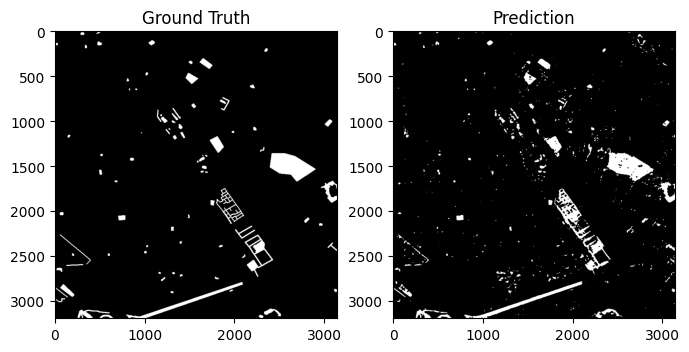

In [13]:
def show_comparison(gt, pred, index=1000):
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(8, 4))
    
    plt.subplot(1, 2, 1)
    plt.title("Ground Truth")
    plt.imshow(gt.reshape(rows_train, cols_train), cmap='gray')
    
    plt.subplot(1, 2, 2)
    plt.title("Prediction")
    plt.imshow(pred.reshape(rows_train, cols_train), cmap='gray')
    

    plt.show()

show_comparison(y_all, final_clean)


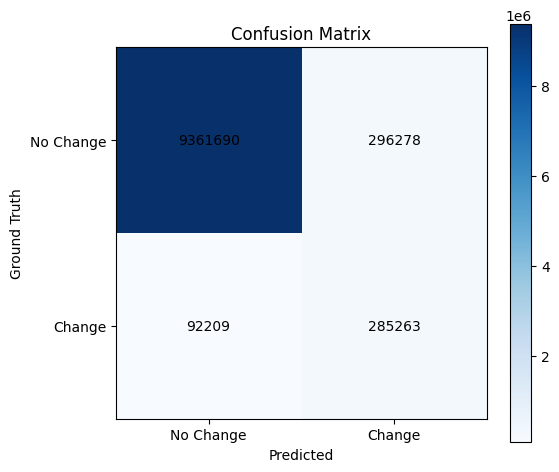

In [20]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["No Change","Change"]

plt.xticks(np.arange(2), classes)
plt.yticks(np.arange(2), classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black")

plt.xlabel("Predicted")
plt.ylabel("Ground Truth")

plt.tight_layout()
plt.show()


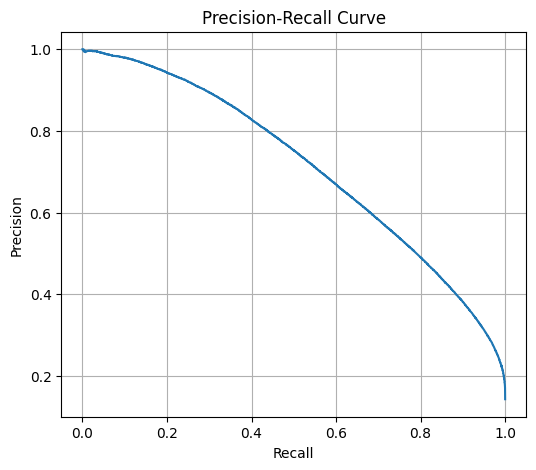

In [22]:
plt.figure(figsize=(6,5))

plt.plot(recalls, precisions)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision‑Recall Curve")

plt.grid(True)

plt.show()


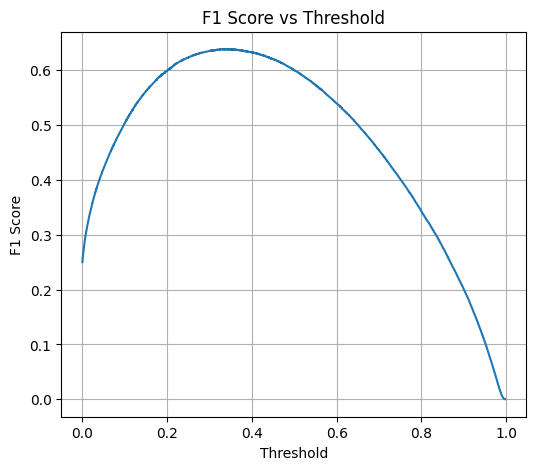

In [23]:
plt.figure(figsize=(6,5))

plt.plot(thresholds, f1_scores[:-1])

plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.title("F1 Score vs Threshold")

plt.grid(True)

plt.show()


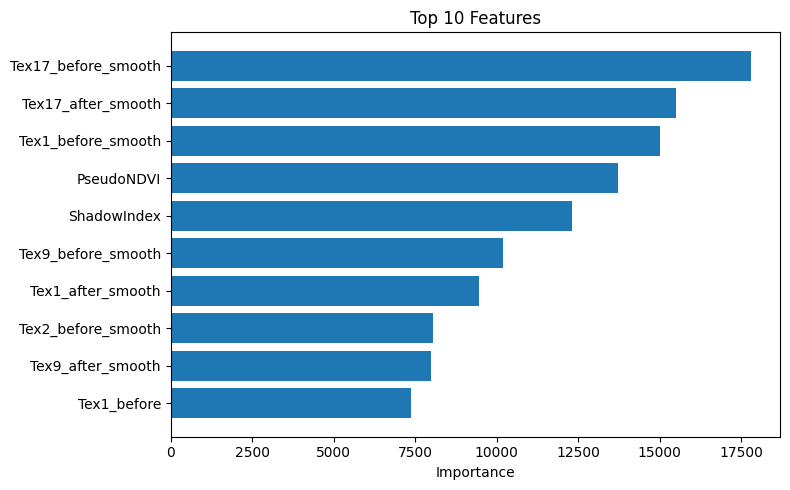

In [24]:
top10_idx = np.argsort(importances)[-10:]
top10_names = [feature_names[i] for i in top10_idx]

plt.figure(figsize=(8,5))

plt.barh(range(10), importances[top10_idx])

plt.yticks(range(10), top10_names)

plt.xlabel("Importance")
plt.title("Top 10 Features")

plt.tight_layout()
plt.show()


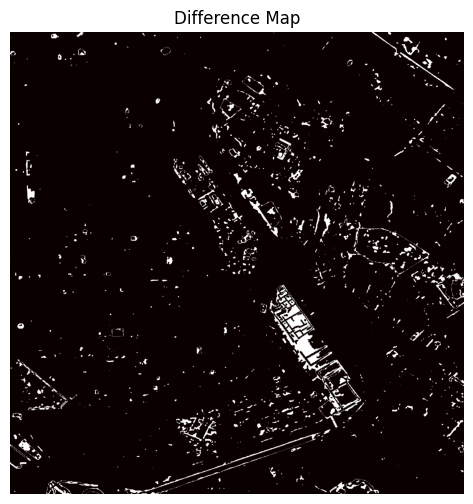

In [26]:
diff_map = np.abs((mask==2).astype(int) - final_clean)

plt.figure(figsize=(6,6))

plt.imshow(diff_map, cmap="hot")

plt.title("Difference Map")

plt.axis("off")

plt.show()


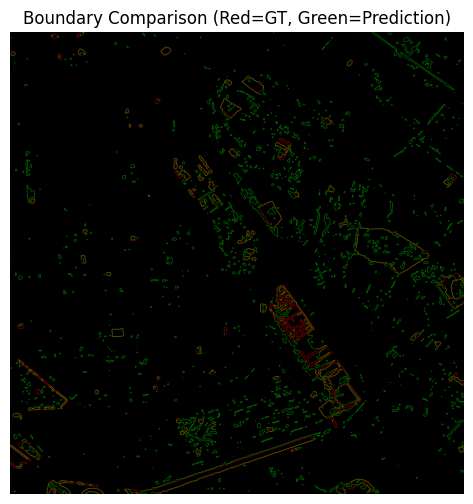

In [27]:
from skimage.segmentation import find_boundaries

b_gt = find_boundaries(mask==2, mode='thick')
b_pr = find_boundaries(final_clean, mode='thick')

overlay = np.zeros((rows_train, cols_train, 3))

overlay[:,:,0] = b_gt
overlay[:,:,1] = b_pr

plt.figure(figsize=(6,6))

plt.imshow(overlay)

plt.title("Boundary Comparison (Red=GT, Green=Prediction)")

plt.axis("off")

plt.show()


Loading data EDSR...
Balancing dataset...


C:\Users\dga\AppData\Local\Temp\ipykernel_1872\3788418054.py:133: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))


Training LightGBM...
[LightGBM] [Info] Number of positive: 264230, number of negative: 1585382
[LightGBM] [Info] Total Bins 35491
[LightGBM] [Info] Number of data points in the train set: 1849612, number of used features: 156
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166666 -> initscore=-1.609439
[LightGBM] [Info] Start training from score -1.609439
[LightGBM] [Info] Number of positive: 264230, number of negative: 1585382
[LightGBM] [Info] Total Bins 12505
[LightGBM] [Info] Number of data points in the train set: 1849612, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166666 -> initscore=-1.609439
[LightGBM] [Info] Start training from score -1.609439


f:\anaconda\envs\remote_sensing\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold: 0.36929469244462254
Generating full map...


C:\Users\dga\AppData\Local\Temp\ipykernel_1872\3788418054.py:133: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
f:\anaconda\envs\remote_sensing\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\dga\AppData\Local\Temp\ipykernel_1872\3788418054.py:133: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
f:\anaconda\envs\remote_sensing\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\dga\AppData\Local\Temp\ipykernel_1872\3788418054.py:133: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
f:\anaconda\envs\remote_sensing\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have vali

Kappa: 0.7435
IoU: 0.6055
MCC: 0.7492
Balanced Accuracy: 0.9193
Precision: 0.6750
Recall: 0.8547
F1-score: 0.7543
Boundary IoU: 0.0504
Hausdorff Distance: 114024.00

Classification Report:
              precision    recall  f1-score   support

           0     0.9943    0.9839    0.9891   9657968
           1     0.6750    0.8547    0.7543    377472

    accuracy                         0.9791  10035440
   macro avg     0.8346    0.9193    0.8717  10035440
weighted avg     0.9823    0.9791    0.9802  10035440



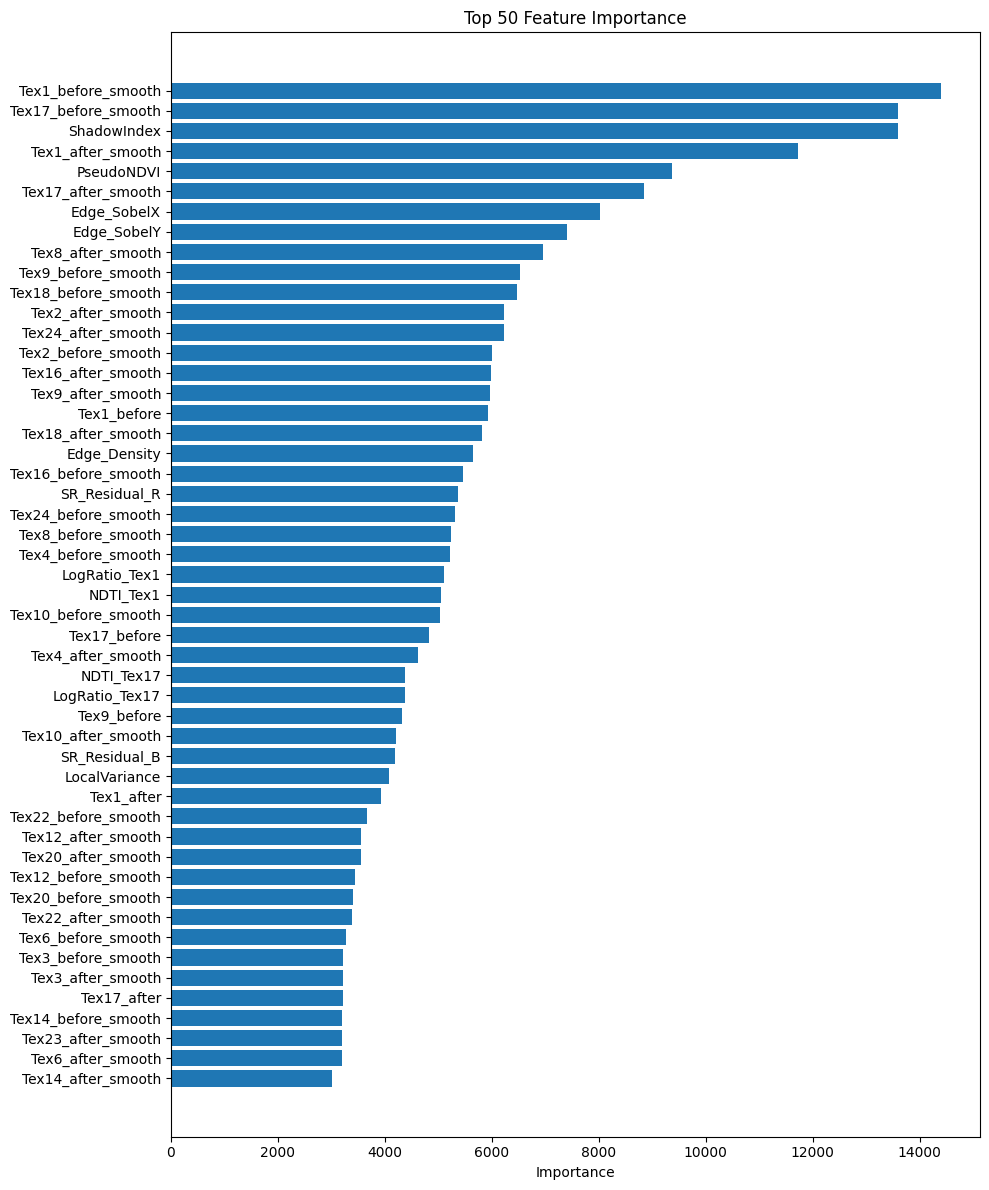

Pipeline finished.


In [ ]:
# For choice Sr - EDSR  
import numpy as np
import cv2
import os
import gc
import joblib
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report,
    cohen_kappa_score,
    precision_recall_curve,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_score,
    recall_score,
)
from skimage.segmentation import find_boundaries
from scipy.spatial.distance import directed_hausdorff


# PATHS AND GLOBAL PARAMETERS

rows_train, cols_train, bands = 3196, 3140, 24

base_dir = r"F:\SR_CHANGE_DET"

path_envi_before = os.path.join(base_dir, "EDSR", "Sr_abefore_ESsr_ext", "Before")
path_envi_after = os.path.join(base_dir, "EDSR", "SR_after_EDsr_extrac", "After")
path_raw_after = os.path.join(base_dir, "EDSR", "after_SR(2).png")

mask_path = os.path.join(base_dir, "abudhabi", "cm", "abudhabi-cm.tif")

# FEATURE NAMES SETUP

texture_names = [f"Tex{i+1}" for i in range(bands)]

feature_names = []

for n in texture_names:
    feature_names.append(f"{n}_after")

for n in texture_names:
    feature_names.append(f"{n}_before")

for n in texture_names:
    feature_names.append(f"NDTI_{n}")

for n in texture_names:
    feature_names.append(f"LogRatio_{n}")

for n in texture_names:
    feature_names.append(f"{n}_after_smooth")

for n in texture_names:
    feature_names.append(f"{n}_before_smooth")

feature_names += [
    "LocalVariance",
    "PseudoNDVI",
    "Brightness",
    "ShadowIndex",
    "Edge_SobelX",
    "Edge_SobelY",
    "Edge_Gradient",
    "Edge_Laplacian",
    "Edge_Density",
    "SR_Residual_R",
    "SR_Residual_G",
    "SR_Residual_B"
]


# LOAD ENVI DATA HELPER FUNCTION

def load_envi_fast(path, r, c, b):
    data = np.fromfile(path, dtype=np.float32)
    data = data.reshape(b, r, c).transpose(1, 2, 0)
    return data


# EDGE FEATURE EXTRACTION

def compute_edge_features(gray):
    sobelx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx ** 2 + sobely ** 2)
    lap = cv2.Laplacian(gray, cv2.CV_32F)
    edges = cv2.Canny(gray.astype(np.uint8), 30, 100)  # حساس‌تر به لبه‌ها
    edge_density = cv2.blur(edges.astype(np.float32), (7, 7))
    return sobelx, sobely, grad_mag, lap, edge_density


# FEATURE EXTRACTION

def get_features_v4(envi_b, envi_a, img_var, indices, rgb_after,
                    sobelx, sobely, grad, lap, edge_den, sr_residual):

    eb = envi_b.reshape(-1, bands)[indices]
    ea = envi_a.reshape(-1, bands)[indices]

    iv = img_var.flatten()[indices][:, None]

    rgb = rgb_after.reshape(-1, 3)[indices]
    R, G, B = rgb[:, 0], rgb[:, 1], rgb[:, 2]

    brightness = np.mean(rgb, axis=1)[:, None]

    p_ndvi = (G - R) / (G + R + 1e-6)
    p_ndvi = p_ndvi[:, None]

    shadow = (B - R) / (B + R + 1e-6)
    shadow = shadow[:, None]

    eps = 1e-6

    ndti = np.abs(ea - eb) / (ea + eb + eps)
    log_ratio = np.log((ea + eps) / (eb + eps))
    log_ratio = np.nan_to_num(log_ratio)

    ea_s = cv2.blur(envi_a, (5, 5)).reshape(-1, bands)[indices]
    eb_s = cv2.blur(envi_b, (5, 5)).reshape(-1, bands)[indices]

    edge_feats = np.stack([
        sobelx.flatten()[indices],
        sobely.flatten()[indices],
        grad.flatten()[indices],
        lap.flatten()[indices],
        edge_den.flatten()[indices]
    ], axis=1)

    sr_res = sr_residual.reshape(-1, 3)[indices]

    return np.concatenate([
        ea, eb,
        ndti,
        log_ratio,
        ea_s, eb_s,
        iv,
        p_ndvi,
        brightness,
        shadow,
        edge_feats,
        sr_res
    ], axis=-1)


# LOAD DATA SECTION

print("Loading data EDSR...")

envi_b = load_envi_fast(path_envi_before, rows_train, cols_train, bands)
envi_a = load_envi_fast(path_envi_after, rows_train, cols_train, bands)

raw_sr = cv2.imread(path_raw_after)
raw_sr = cv2.cvtColor(raw_sr, cv2.COLOR_BGR2RGB)
raw_sr = cv2.resize(raw_sr, (cols_train, rows_train))
raw_sr = raw_sr.astype(np.float32) / 255


# LOCAL VARIANCE CALCULATION

gray = cv2.cvtColor((raw_sr * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32)
mean = cv2.blur(gray, (7, 7))
img_var = np.sqrt(np.maximum(cv2.blur(gray ** 2, (7, 7)) - mean ** 2, 0))


# EDGE FEATURES

sobelx, sobely, grad, lap, edge_den = compute_edge_features(gray)


# SR RESIDUAL

bicubic = cv2.resize(cv2.resize(raw_sr, (cols_train // 4, rows_train // 4)), (cols_train, rows_train))
sr_residual = raw_sr - bicubic


# LOAD MASK

mask = cv2.imread(mask_path, 0)
mask = cv2.resize(mask, (cols_train, rows_train), interpolation=cv2.INTER_NEAREST)

y_all = (mask.flatten() == 2).astype(np.uint8)


# DATA BALANCING

print("Balancing dataset...")

idx_change = np.where(y_all == 1)[0]
idx_no_change = np.random.choice(np.where(y_all == 0)[0], size=len(idx_change) * 6, replace=False)
all_idx = np.concatenate([idx_change, idx_no_change])

X = get_features_v4(envi_b, envi_a, img_var, all_idx, raw_sr, sobelx, sobely, grad, lap, edge_den, sr_residual)
y = y_all[all_idx]


# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# TRAIN LIGHTGBM MODEL

print("Training LightGBM...")

model = lgb.LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    num_leaves=255,
    class_weight={0: 1, 1: 1.2},
    force_col_wise=True
)

model.fit(X_train, y_train)


# FEATURE IMPORTANCE AND SELECTION

importances = model.feature_importances_
top50 = np.argsort(importances)[-50:]
top50_names = [feature_names[i] for i in top50]

X_train = X_train[:, top50]
X_test = X_test[:, top50]

model.fit(X_train, y_train)


# FIND BEST THRESHOLD

probs = model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_th = thresholds[np.argmax(f1_scores)]

print("Best threshold:", best_th)

# FULL MAP PREDICTION 

print("Generating full map...")

step = 100
full_pred = np.zeros(rows_train * cols_train, dtype=np.uint8)

for r in range(0, rows_train, step):
    r_end = min(r + step, rows_train)
    indices = np.arange(r * cols_train, r_end * cols_train)
    X_block = get_features_v4(envi_b, envi_a, img_var, indices, raw_sr,
                              sobelx, sobely, grad, lap, edge_den, sr_residual)
    X_block = scaler.transform(X_block)
    X_block = X_block[:, top50]
    probs = model.predict_proba(X_block)[:, 1]
    full_pred[indices] = (probs >= best_th).astype(np.uint8)
    del X_block
    gc.collect()

final_map = full_pred.reshape(rows_train, cols_train)

# POST-PROCESSING 

final_clean = cv2.medianBlur(final_map.astype(np.uint8), 11)
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
final_clean = cv2.morphologyEx(final_clean, cv2.MORPH_CLOSE, kernel_close)
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
final_clean = cv2.morphologyEx(final_clean, cv2.MORPH_OPEN, kernel_open)


# METRIC FUNCTIONS INCLUDING BOUNDARY IOU AND HAUSDORFF

def boundary_iou(y_true, y_pred):
    boundary_true = find_boundaries(y_true, mode='thick').astype(np.uint8)
    boundary_pred = find_boundaries(y_pred, mode='thick').astype(np.uint8)
    intersection = np.logical_and(boundary_true, boundary_pred).sum()
    union = np.logical_or(boundary_true, boundary_pred).sum()
    if union == 0:
        return 1.0  
    return intersection / union


def hausdorff_distance(y_true, y_pred):
    boundary_true = find_boundaries(y_true, mode='thick').astype(np.uint8)
    boundary_pred = find_boundaries(y_pred, mode='thick').astype(np.uint8)
    points_true = np.argwhere(boundary_true)
    points_pred = np.argwhere(boundary_pred)
    if len(points_true) == 0 or len(points_pred) == 0:
        return np.nan
    hd_forward = directed_hausdorff(points_true, points_pred)[0]
    hd_backward = directed_hausdorff(points_pred, points_true)[0]
    return max(hd_forward, hd_backward)


# COMPUTE METRICS

y_true = y_all
y_pred = final_clean.flatten()

kappa = cohen_kappa_score(y_true, y_pred)
iou = jaccard_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
boundary_iou_val = boundary_iou(y_true, y_pred)
hausdorff_val = hausdorff_distance(y_true, y_pred)

print(f"Kappa: {kappa:.4f}")
print(f"IoU: {iou:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Boundary IoU: {boundary_iou_val:.4f}")
print(f"Hausdorff Distance: {hausdorff_val:.2f}")


# DISPLAY FULL CLASSIFICATION REPORT

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# FEATURE IMPORTANCE PLOT

plt.figure(figsize=(10, 12))
plt.barh(range(50), importances[top50])
plt.yticks(range(50), top50_names)
plt.title("Top 50 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "SR_RealESRGAN_FeatureImportance.png"), dpi=300)
plt.show()



# SAVE MODEL AND FEATURE NAMES

joblib.dump(top50_names, os.path.join(base_dir, "SR_LGBM_V4_top50_feature_names.pkl"))
joblib.dump(model, os.path.join(base_dir, "SR_LGBM_V4_model.pkl"))

print("Pipeline finished.")

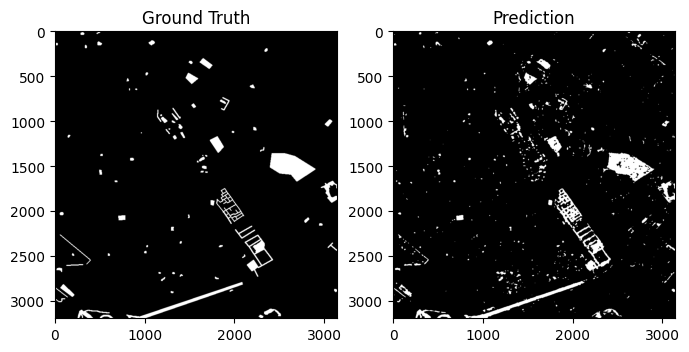

In [27]:
def show_comparison(gt, pred, index=1000):
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(8, 4))
    
    plt.subplot(1, 2, 1)
    plt.title("Ground Truth")
    plt.imshow(gt.reshape(rows_train, cols_train), cmap='gray')
    
    plt.subplot(1, 2, 2)
    plt.title("Prediction")
    plt.imshow(pred.reshape(rows_train, cols_train), cmap='gray')
    

    plt.show()

show_comparison(y_all, final_clean)

XGBOOST CHANGE DETECTION WITH REAL-ESRGAN

Loading data...
ENVI before shape: (3196, 3140, 24)
ENVI after shape: (3196, 3140, 24)
SR image shape: (3196, 3140, 3)
Total pixels: 10035440
Change pixels: 377472 (3.76%)
No-change pixels: 9657968 (96.24%)

Balancing dataset...
Selected indices: 2642304 (Change: 377472, No-change: 2264832)


C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))


Feature matrix shape: (2642304, 156)
Train set: 1849612 samples
Test set: 792692 samples

Training XGBoost Classifier...


f:\anaconda\envs\remote_sensing\lib\site-packages\xgboost\training.py:200: UserWarning: [19:34:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training completed!

Top 5 features:
  1. Edge_SobelX (importance: 0.0058)
  2. Tex23_before_smooth (importance: 0.0063)
  3. Edge_SobelY (importance: 0.0063)
  4. Tex5_after (importance: 0.0067)
  5. Tex15_before_smooth (importance: 0.0067)


...

  Progress: 2500/3196 rows


C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))


  Progress: 3000/3196 rows


C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))


Prediction completed!

Applying post-processing...

RESULTS - XGBOOST WITH REAL-ESRGAN

--- Confusion Matrix ---
True Negatives (TN):  9,347,830
False Positives (FP): 310,138
False Negatives (FN): 108,859
True Positives (TP):  268,613

--- Primary Metrics ---
Overall Accuracy:     0.9582
Balanced Accuracy:    0.8397
Precision:            0.4641
Recall:               0.7116
Specificity:          0.9679
F1-Score:             0.5618

--- Advanced Metrics ---
Cohen's Kappa:        0.5409
IoU (Jaccard):        0.3906
Matthews CC (MCC):    0.5546

--- Boundary & Distance Metrics ---
Boundary IoU:         0.0321
Hausdorff Distance:   752.02

--- Error Rates ---
False Positive Rate:  0.0321
False Negative Rate:  0.2884

--- Classification Report ---
              precision    recall  f1-score   support

   No Change     0.9885    0.9679    0.9781   9657968
      Change     0.4641    0.7116    0.5618    377472

    accuracy                         0.9582  10035440
   macro avg     0.7263    0.8

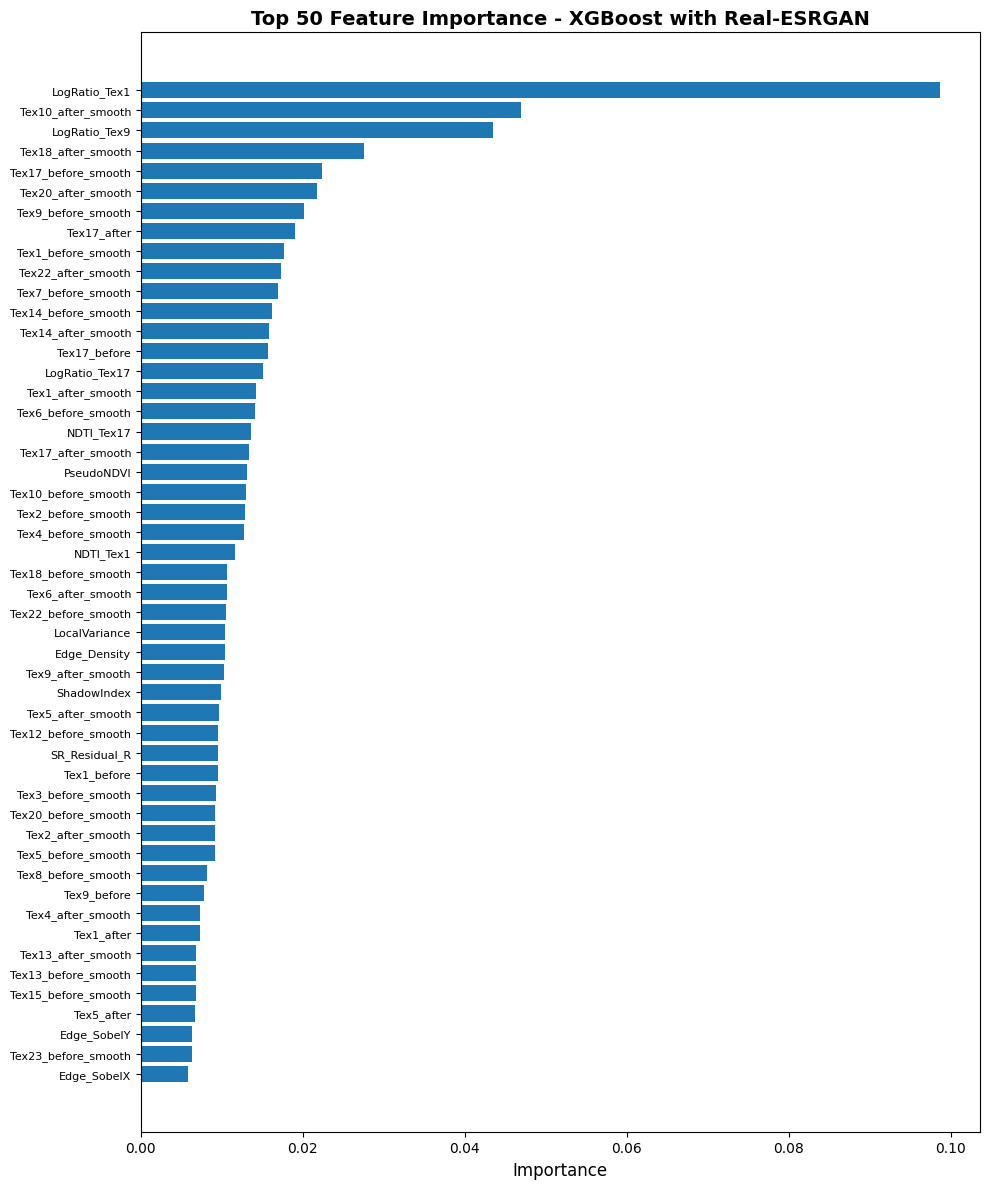


RESULTS SAVED:
  - Model: F:\SR_CHANGE_DET\XGBoost_RealESRGAN_model1.pkl
  - Scaler: F:\SR_CHANGE_DET\XGBoost_RealESRGAN_scaler1.pkl
  - Feature names: F:\SR_CHANGE_DET\XGBoost_RealESRGAN_top50_names1.pkl
  - Prediction map: F:\SR_CHANGE_DET\XGBoost_RealESRGAN_Final_Map1.png
  - Metrics: F:\SR_CHANGE_DET\XGBoost_RealESRGAN_Results1.txt

Pipeline finished successfully!


In [2]:
# ============================================================
# XGBOOST CHANGE DETECTION WITH REAL-ESRGAN SUPER-RESOLUTION
# ============================================================

import numpy as np
import cv2
import os
import gc
import joblib
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report,
    cohen_kappa_score,
    precision_recall_curve,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix
)
from skimage.segmentation import find_boundaries
from scipy.spatial.distance import directed_hausdorff


# ===========================
# PATHS AND GLOBAL PARAMETERS
# ===========================

rows_train, cols_train, bands = 3196, 3140, 24

base_dir = r"F:\SR_CHANGE_DET"

path_envi_before = os.path.join(base_dir, "Real_Gan", "before_TEX", "FILE_before")
path_envi_after = os.path.join(base_dir, "Real_Gan", "after_TEXTure", "File_after")
path_raw_after = os.path.join(base_dir, "Real_Gan", "sr_after.png")

mask_path = os.path.join(base_dir, "abudhabi", "cm", "abudhabi-cm.tif")

# ===================
# FEATURE NAMES SETUP
# ===================

texture_names = [f"Tex{i+1}" for i in range(bands)]

feature_names = []

for n in texture_names:
    feature_names.append(f"{n}_after")

for n in texture_names:
    feature_names.append(f"{n}_before")

for n in texture_names:
    feature_names.append(f"NDTI_{n}")

for n in texture_names:
    feature_names.append(f"LogRatio_{n}")

for n in texture_names:
    feature_names.append(f"{n}_after_smooth")

for n in texture_names:
    feature_names.append(f"{n}_before_smooth")

feature_names += [
    "LocalVariance",
    "PseudoNDVI",
    "Brightness",
    "ShadowIndex",
    "Edge_SobelX",
    "Edge_SobelY",
    "Edge_Gradient",
    "Edge_Laplacian",
    "Edge_Density",
    "SR_Residual_R",
    "SR_Residual_G",
    "SR_Residual_B"
]


# =============================
# LOAD ENVI DATA HELPER FUNCTION
# =============================

def load_envi_fast(path, r, c, b):
    data = np.fromfile(path, dtype=np.float32)
    data = data.reshape(b, r, c).transpose(1, 2, 0)
    return data


# ========================
# EDGE FEATURE EXTRACTION
# ========================

def compute_edge_features(gray):
    sobelx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx ** 2 + sobely ** 2)
    lap = cv2.Laplacian(gray, cv2.CV_32F)
    edges = cv2.Canny(gray.astype(np.uint8), 30, 100)
    edge_density = cv2.blur(edges.astype(np.float32), (7, 7))
    return sobelx, sobely, grad_mag, lap, edge_density


# ==================
# FEATURE EXTRACTION
# ==================

def get_features_v4(envi_b, envi_a, img_var, indices, rgb_after,
                    sobelx, sobely, grad, lap, edge_den, sr_residual):

    eb = envi_b.reshape(-1, bands)[indices]
    ea = envi_a.reshape(-1, bands)[indices]

    iv = img_var.flatten()[indices][:, None]

    rgb = rgb_after.reshape(-1, 3)[indices]
    R, G, B = rgb[:, 0], rgb[:, 1], rgb[:, 2]

    brightness = np.mean(rgb, axis=1)[:, None]

    p_ndvi = (G - R) / (G + R + 1e-6)
    p_ndvi = p_ndvi[:, None]

    shadow = (B - R) / (B + R + 1e-6)
    shadow = shadow[:, None]

    eps = 1e-6

    ndti = np.abs(ea - eb) / (ea + eb + eps)
    log_ratio = np.log((ea + eps) / (eb + eps))
    log_ratio = np.nan_to_num(log_ratio)

    ea_s = cv2.blur(envi_a, (5, 5)).reshape(-1, bands)[indices]
    eb_s = cv2.blur(envi_b, (5, 5)).reshape(-1, bands)[indices]

    edge_feats = np.stack([
        sobelx.flatten()[indices],
        sobely.flatten()[indices],
        grad.flatten()[indices],
        lap.flatten()[indices],
        edge_den.flatten()[indices]
    ], axis=1)

    sr_res = sr_residual.reshape(-1, 3)[indices]

    return np.concatenate([
        ea, eb,
        ndti,
        log_ratio,
        ea_s, eb_s,
        iv,
        p_ndvi,
        brightness,
        shadow,
        edge_feats,
        sr_res
    ], axis=-1)


# =================
# LOAD DATA SECTION
# =================

print("=" * 60)
print("XGBOOST CHANGE DETECTION WITH REAL-ESRGAN")
print("=" * 60)

print("\nLoading data...")

envi_b = load_envi_fast(path_envi_before, rows_train, cols_train, bands)
envi_a = load_envi_fast(path_envi_after, rows_train, cols_train, bands)

raw_sr = cv2.imread(path_raw_after)
raw_sr = cv2.cvtColor(raw_sr, cv2.COLOR_BGR2RGB)
raw_sr = cv2.resize(raw_sr, (cols_train, rows_train))
raw_sr = raw_sr.astype(np.float32) / 255

print(f"ENVI before shape: {envi_b.shape}")
print(f"ENVI after shape: {envi_a.shape}")
print(f"SR image shape: {raw_sr.shape}")


# ====================
# LOCAL VARIANCE CALCULATION
# ====================

gray = cv2.cvtColor((raw_sr * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32)
mean = cv2.blur(gray, (7, 7))
img_var = np.sqrt(np.maximum(cv2.blur(gray ** 2, (7, 7)) - mean ** 2, 0))


# ===============
# EDGE FEATURES
# ===============

sobelx, sobely, grad, lap, edge_den = compute_edge_features(gray)


# ===============
# SR RESIDUAL
# ===============

bicubic = cv2.resize(cv2.resize(raw_sr, (cols_train // 4, rows_train // 4)), (cols_train, rows_train))
sr_residual = raw_sr - bicubic


# ===========
# LOAD MASK
# ===========

mask = cv2.imread(mask_path, 0)
mask = cv2.resize(mask, (cols_train, rows_train), interpolation=cv2.INTER_NEAREST)

y_all = (mask.flatten() == 2).astype(np.uint8)

print(f"Total pixels: {len(y_all)}")
print(f"Change pixels: {np.sum(y_all)} ({np.sum(y_all)/len(y_all)*100:.2f}%)")
print(f"No-change pixels: {len(y_all)-np.sum(y_all)} ({(len(y_all)-np.sum(y_all))/len(y_all)*100:.2f}%)")


# ======================
# DATA BALANCING
# ======================

print("\nBalancing dataset...")

idx_change = np.where(y_all == 1)[0]
idx_no_change = np.random.choice(np.where(y_all == 0)[0], size=len(idx_change) * 6, replace=False)
all_idx = np.concatenate([idx_change, idx_no_change])

print(f"Selected indices: {len(all_idx)} (Change: {len(idx_change)}, No-change: {len(idx_no_change)})")

X = get_features_v4(envi_b, envi_a, img_var, all_idx, raw_sr, sobelx, sobely, grad, lap, edge_den, sr_residual)
y = y_all[all_idx]

print(f"Feature matrix shape: {X.shape}")


# ============
# TRAIN-TEST SPLIT
# ============

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ===========
# TRAIN XGBOOST MODEL
# ===========

print("\nTraining XGBoost Classifier...")

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.2,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train, verbose=False)

print("Training completed!")


# ====================
# FEATURE IMPORTANCE AND SELECTION (Top 50)
# ====================

importances = model.feature_importances_
top50 = np.argsort(importances)[-50:]
top50_names = [feature_names[i] for i in top50]

print(f"\nTop 5 features:")
for i in range(5):
    print(f"  {i+1}. {top50_names[i]} (importance: {importances[top50[i]]:.4f})")

X_train = X_train[:, top50]
X_test = X_test[:, top50]

model.fit(X_train, y_train, verbose=False)


# =====================
# FIND BEST THRESHOLD
# =====================

probs = model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_th = thresholds[np.argmax(f1_scores)]

print(f"\nBest threshold: {best_th:.4f}")


# =============================
# FULL MAP PREDICTION
# =============================

print("\nGenerating full prediction map...")

step = 100
full_pred = np.zeros(rows_train * cols_train, dtype=np.uint8)

for r in range(0, rows_train, step):
    r_end = min(r + step, rows_train)
    indices = np.arange(r * cols_train, r_end * cols_train)
    
    X_block = get_features_v4(envi_b, envi_a, img_var, indices, raw_sr,
                              sobelx, sobely, grad, lap, edge_den, sr_residual)
    X_block = scaler.transform(X_block)
    X_block = X_block[:, top50]
    probs = model.predict_proba(X_block)[:, 1]
    full_pred[indices] = (probs >= best_th).astype(np.uint8)
    
    del X_block
    gc.collect()
    
    if r % 500 == 0:
        print(f"  Progress: {r}/{rows_train} rows")

final_map = full_pred.reshape(rows_train, cols_train)
print("Prediction completed!")


# ===================
# POST-PROCESSING
# ===================

print("\nApplying post-processing...")

final_clean = cv2.medianBlur(final_map.astype(np.uint8), 11)
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
final_clean = cv2.morphologyEx(final_clean, cv2.MORPH_CLOSE, kernel_close)
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
final_clean = cv2.morphologyEx(final_clean, cv2.MORPH_OPEN, kernel_open)


# =========================
# METRIC FUNCTIONS
# =========================

def boundary_iou(y_true, y_pred):
    yt = y_true.reshape(rows_train, cols_train).astype(np.uint8)
    yp = y_pred.reshape(rows_train, cols_train).astype(np.uint8)
    boundary_true = find_boundaries(yt, mode='thick').astype(np.uint8)
    boundary_pred = find_boundaries(yp, mode='thick').astype(np.uint8)
    intersection = np.logical_and(boundary_true, boundary_pred).sum()
    union = np.logical_or(boundary_true, boundary_pred).sum()
    if union == 0:
        return 1.0
    return intersection / union


def hausdorff_distance(y_true, y_pred):
    yt = y_true.reshape(rows_train, cols_train).astype(np.uint8)
    yp = y_pred.reshape(rows_train, cols_train).astype(np.uint8)
    boundary_true = find_boundaries(yt, mode='thick').astype(np.uint8)
    boundary_pred = find_boundaries(yp, mode='thick').astype(np.uint8)
    points_true = np.argwhere(boundary_true)
    points_pred = np.argwhere(boundary_pred)
    if len(points_true) == 0 or len(points_pred) == 0:
        return np.nan
    hd_forward = directed_hausdorff(points_true, points_pred)[0]
    hd_backward = directed_hausdorff(points_pred, points_true)[0]
    return max(hd_forward, hd_backward)


# =====================
# COMPUTE ALL METRICS
# =====================

print("\n" + "=" * 60)
print("RESULTS - XGBOOST WITH REAL-ESRGAN")
print("=" * 60)

y_true = y_all
y_pred = final_clean.flatten()

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

# Basic metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
iou = jaccard_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)

# Boundary metrics
boundary_iou_val = boundary_iou(y_true, y_pred)
hausdorff_val = hausdorff_distance(y_true, y_pred)

# Error rates
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print("\n--- Confusion Matrix ---")
print(f"True Negatives (TN):  {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives (TP):  {tp:,}")

print("\n--- Primary Metrics ---")
print(f"Overall Accuracy:     {accuracy:.4f}")
print(f"Balanced Accuracy:    {bal_acc:.4f}")
print(f"Precision:            {precision:.4f}")
print(f"Recall:               {recall:.4f}")
print(f"Specificity:          {specificity:.4f}")
print(f"F1-Score:             {f1:.4f}")

print("\n--- Advanced Metrics ---")
print(f"Cohen's Kappa:        {kappa:.4f}")
print(f"IoU (Jaccard):        {iou:.4f}")
print(f"Matthews CC (MCC):    {mcc:.4f}")

print("\n--- Boundary & Distance Metrics ---")
print(f"Boundary IoU:         {boundary_iou_val:.4f}")
print(f"Hausdorff Distance:   {hausdorff_val:.2f}")

print("\n--- Error Rates ---")
print(f"False Positive Rate:  {fpr:.4f}")
print(f"False Negative Rate:  {fnr:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['No Change', 'Change'], digits=4))


# ======================
# FEATURE IMPORTANCE PLOT
# ======================

plt.figure(figsize=(10, 12))
plt.barh(range(50), importances[top50])
plt.yticks(range(50), top50_names, fontsize=8)
plt.xlabel('Importance', fontsize=12)
plt.title("Top 50 Feature Importance - XGBoost with Real-ESRGAN", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "XGBoost_RealESRGAN_FeatureImportance.png"), dpi=300)
plt.show()


# =====================
# SAVE RESULTS
# =====================

# Save model and scaler
joblib.dump(model, os.path.join(base_dir, "XGBoost_RealESRGAN_model1.pkl"))
joblib.dump(scaler, os.path.join(base_dir, "XGBoost_RealESRGAN_scaler1.pkl"))
joblib.dump(top50_names, os.path.join(base_dir, "XGBoost_RealESRGAN_top50_names1.pkl"))

# Save prediction map
cv2.imwrite(os.path.join(base_dir, "XGBoost_RealESRGAN_Final_Map1.png"), final_clean * 255)

# Save metrics to text file
with open(os.path.join(base_dir, "XGBoost_RealESRGAN_Results1.txt"), "w") as f:
    f.write("XGBOOST WITH REAL-ESRGAN - RESULTS\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Accuracy:           {accuracy:.4f}\n")
    f.write(f"Balanced Accuracy:  {bal_acc:.4f}\n")
    f.write(f"Precision:          {precision:.4f}\n")
    f.write(f"Recall:             {recall:.4f}\n")
    f.write(f"Specificity:        {specificity:.4f}\n")
    f.write(f"F1-Score:           {f1:.4f}\n")
    f.write(f"Kappa:              {kappa:.4f}\n")
    f.write(f"IoU:                {iou:.4f}\n")
    f.write(f"MCC:                {mcc:.4f}\n")
    f.write(f"Boundary IoU:       {boundary_iou_val:.4f}\n")
    f.write(f"Hausdorff Distance: {hausdorff_val:.2f}\n")
    f.write(f"FPR:                {fpr:.4f}\n")
    f.write(f"FNR:                {fnr:.4f}\n")

print("\n" + "=" * 60)
print("RESULTS SAVED:")
print(f"  - Model: {os.path.join(base_dir, 'XGBoost_RealESRGAN_model1.pkl')}")
print(f"  - Scaler: {os.path.join(base_dir, 'XGBoost_RealESRGAN_scaler1.pkl')}")
print(f"  - Feature names: {os.path.join(base_dir, 'XGBoost_RealESRGAN_top50_names1.pkl')}")
print(f"  - Prediction map: {os.path.join(base_dir, 'XGBoost_RealESRGAN_Final_Map1.png')}")
print(f"  - Metrics: {os.path.join(base_dir, 'XGBoost_RealESRGAN_Results1.txt')}")
print("=" * 60)

print("\nPipeline finished successfully!")

In [3]:
# ===========
# TRAIN RANDOM FOREST MODEL
# ===========

print("\nTraining Random Forest Classifier...")

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight={0: 1, 1: 1.2},
    random_state=42,
    n_jobs=-1  # استفاده از همه هسته‌های پردازنده برای سرعت بیشتر
)

model.fit(X_train, y_train)

print("Training completed!")


Training Random Forest Classifier...
Training completed!


In [5]:
# =====================
# COMPUTE METRICS FOR RANDOM FOREST
# =====================

print("\n" + "=" * 60)
print("RESULTS - RANDOM FOREST WITH REAL-ESRGAN")
print("=" * 60)

# پیش‌بینی روی داده تست
y_pred_test = model.predict(X_test)

# معیارهای پایه
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
kappa = cohen_kappa_score(y_test, y_pred_test)

print(f"Accuracy:           {accuracy:.4f}")
print(f"Precision:          {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"F1-Score:           {f1:.4f}")
print(f"Kappa:              {kappa:.4f}")

# =====================
# FULL MAP PREDICTION (LIKE XGBOOST)
# =====================

print("\nGenerating full prediction map...")

step = 100
full_pred = np.zeros(rows_train * cols_train, dtype=np.uint8)

for r in range(0, rows_train, step):
    r_end = min(r + step, rows_train)
    indices = np.arange(r * cols_train, r_end * cols_train)
    
    X_block = get_features_v4(envi_b, envi_a, img_var, indices, raw_sr,
                              sobelx, sobely, grad, lap, edge_den, sr_residual)
    X_block = scaler.transform(X_block)
    X_block = X_block[:, top50]
    preds = model.predict(X_block)
    full_pred[indices] = preds
    
    del X_block
    gc.collect()
    
    if r % 500 == 0:
        print(f"  Progress: {r}/{rows_train} rows")

final_map = full_pred.reshape(rows_train, cols_train)
print("Prediction completed!")

# ===================
# POST-PROCESSING
# ===================

print("\nApplying post-processing...")

final_clean = cv2.medianBlur(final_map.astype(np.uint8), 11)
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
final_clean = cv2.morphologyEx(final_clean, cv2.MORPH_CLOSE, kernel_close)
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
final_clean = cv2.morphologyEx(final_clean, cv2.MORPH_OPEN, kernel_open)

# =====================
# BOUNDARY METRICS
# =====================

def boundary_iou(y_true, y_pred):
    yt = y_true.reshape(rows_train, cols_train).astype(np.uint8)
    yp = y_pred.reshape(rows_train, cols_train).astype(np.uint8)
    boundary_true = find_boundaries(yt, mode='thick').astype(np.uint8)
    boundary_pred = find_boundaries(yp, mode='thick').astype(np.uint8)
    intersection = np.logical_and(boundary_true, boundary_pred).sum()
    union = np.logical_or(boundary_true, boundary_pred).sum()
    if union == 0:
        return 1.0
    return intersection / union

def hausdorff_distance(y_true, y_pred):
    yt = y_true.reshape(rows_train, cols_train).astype(np.uint8)
    yp = y_pred.reshape(rows_train, cols_train).astype(np.uint8)
    boundary_true = find_boundaries(yt, mode='thick').astype(np.uint8)
    boundary_pred = find_boundaries(yp, mode='thick').astype(np.uint8)
    points_true = np.argwhere(boundary_true)
    points_pred = np.argwhere(boundary_pred)
    if len(points_true) == 0 or len(points_pred) == 0:
        return np.nan
    hd_forward = directed_hausdorff(points_true, points_pred)[0]
    hd_backward = directed_hausdorff(points_pred, points_true)[0]
    return max(hd_forward, hd_backward)

# محاسبه معیارهای مرزی روی کل نقشه
y_true_full = y_all
y_pred_full = final_clean.flatten()

boundary_iou_val = boundary_iou(y_true_full, y_pred_full)
hausdorff_val = hausdorff_distance(y_true_full, y_pred_full)

print(f"\n--- Boundary & Distance Metrics ---")
print(f"Boundary IoU:         {boundary_iou_val:.4f}")
print(f"Hausdorff Distance:   {hausdorff_val:.2f}")

# =====================
# SAVE RESULTS
# =====================

# Save prediction map
cv2.imwrite(os.path.join(base_dir, "RandomForest_RealESRGAN_Final_Map.png"), final_clean * 255)

# Save metrics to text file
with open(os.path.join(base_dir, "RandomForest_RealESRGAN_Results.txt"), "w") as f:
    f.write("RANDOM FOREST WITH REAL-ESRGAN - RESULTS\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Accuracy:           {accuracy:.4f}\n")
    f.write(f"Precision:          {precision:.4f}\n")
    f.write(f"Recall:             {recall:.4f}\n")
    f.write(f"F1-Score:           {f1:.4f}\n")
    f.write(f"Kappa:              {kappa:.4f}\n")
    f.write(f"Boundary IoU:       {boundary_iou_val:.4f}\n")
    f.write(f"Hausdorff Distance: {hausdorff_val:.2f}\n")

print("\nResults saved successfully!")


RESULTS - RANDOM FOREST WITH REAL-ESRGAN
Accuracy:           0.9323
Precision:          0.8970
Recall:             0.5946
F1-Score:           0.7152
Kappa:              0.6785

Generating full prediction map...


C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))


  Progress: 0/3196 rows


C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))


  Progress: 500/3196 rows


...

  Progress: 2500/3196 rows


C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))
C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))


  Progress: 3000/3196 rows


C:\Users\dga\AppData\Local\Temp\ipykernel_7680\699554396.py:138: RuntimeWarning: invalid value encountered in log
  log_ratio = np.log((ea + eps) / (eb + eps))


Prediction completed!

Applying post-processing...

--- Boundary & Distance Metrics ---
Boundary IoU:         0.0995
Hausdorff Distance:   610.34

Results saved successfully!
